# Cell Type Classification from Gene Expression Data
### TASIC Dataset | AIMS South Africa | 2025–2026

---

## Pipeline Overview

| Section | Description |
|---------|-------------|
| **1** | Setup & Library Imports |
| **2** | Data Loading |
| **3** | Exploratory Data Analysis (EDA) |
| **4** | Normalization (3 methods compared) |
| **5** | Dimensionality Reduction — PCA & t-SNE |
| **6** | Self-Supervised Learning (SimCLR) | t-SNE on SSL Representations & Training Monitoring |
| **7** |tSimCNE — Three-Stage Training | Visualization


---
## Section 1 — Setup & Library Imports

In [1]:
# Install any missing packages before importing
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "scipy", "-q"])

# ── Standard library ──────────────────────────────────────────────────────
import pickle

# ── Numerical & data libraries ────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.sparse

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn: preprocessing, decomposition, models, metrics ───────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

# ── Deep learning — TensorFlow/Keras ─────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# ── Print version info to confirm environment is correctly set up ─────────
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"TF     : {tf.__version__}")


NumPy  : 2.0.2
Pandas : 2.2.2
TF     : 2.20.0


---
## Section 2 — Data Loading

In [11]:
# Mount Google Drive so we can access the dataset stored there
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# ── Set path to the dataset file ──────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/tasic_subset_1kselectedB.pickle"

# Load the pickle file — it contains a dictionary with all data arrays
data = pickle.load(open(DATA_PATH, "rb"))

# Print the available keys so we know what fields to access
print("Keys in data:", list(data.keys()))


Keys in data: ['counts', 'genes', 'clusters', 'areas', 'clusterColors', 'clusterNames']


/tmp/ipykernel_9938/3078396414.py:5: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  data = pickle.load(open(DATA_PATH, "rb"))


---
## Section 3 — Exploratory Data Analysis (EDA)

In [13]:
# ── Extract core arrays from the loaded data dictionary ──────────────────
counts        = data["counts"]

# Convert to a dense NumPy array if the data is in sparse format
counts_array  = counts.toarray() if scipy.sparse.issparse(counts) else np.array(counts)

genes         = list(data["genes"])       # list of gene names
clusters      = np.array(data["clusters"])  # integer cluster ID per cell
areas         = np.array(data["areas"])     # brain area ID per cell
cluster_names = data["clusterNames"]      # maps cluster ID → human-readable name
cluster_colors= data["clusterColors"]     # maps cluster ID → colour string

n_cells, n_genes = counts_array.shape
print(f"Cells : {n_cells:,}")
print(f"Genes : {n_genes:,}")
print(f"Shape : {counts_array.shape}")


Cells : 5,000
Genes : 1,000
Shape : (5000, 1000)


In [14]:
# ── Build a tidy DataFrame combining gene counts with metadata labels ─────
# This makes it easy to filter and group cells by cluster or brain area
counts_df = pd.DataFrame(counts_array, columns=genes)
counts_df["Cluster"]      = clusters
counts_df["Area"]         = areas
counts_df["Cluster_Name"] = [cluster_names[c] for c in clusters]

# Preview: show the first 10 rows for the first 5 genes plus the label columns
counts_df.iloc[:10, list(range(5)) + [-3, -2, -1]]

,1700047M11Rik,1700063D05Rik,2700046A07Rik,2900052N01Rik,3110035E14Rik,Cluster,Area,Cluster_Name
0,0.0,0.0,0.0,0.0,650.0,93,0,L5 PT ALM Slco2a1
1,0.0,0.0,0.0,0.0,176.0,72,0,L5 IT ALM Npw
2,0.0,0.0,0.0,0.0,3.0,1,0,Lamp5 Fam19a1 Pax6
3,0.0,0.0,0.0,0.0,0.0,7,0,Sncg Slc17a8
4,0.0,0.0,0.0,0.0,0.0,7,0,Sncg Slc17a8
5,0.0,0.0,0.0,0.0,0.0,7,0,Sncg Slc17a8
6,0.0,0.0,0.0,0.0,0.0,0,0,Lamp5 Krt73
7,0.0,0.0,0.0,0.0,0.0,10,0,Sncg Vip Itih5
8,0.0,0.0,0.0,0.0,337.0,73,0,L5 IT ALM Pld5
9,0.0,0.0,0.0,0.0,319.0,65,0,L2/3 IT ALM Macc1 Lrg1


In [15]:
# ── Basic summary statistics of the raw expression matrix ─────────────────
total_vals = counts_array.size
zero_vals  = (counts_array == 0).sum()
pct_zeros  = zero_vals / total_vals * 100

print("─── Dataset Summary ────────────────────────────────────────")
print(f"  Cells               : {n_cells:,}")
print(f"  Genes               : {n_genes:,}")
print(f"  Total values        : {total_vals:,}")
print(f"  Minimum expression  : {counts_array.min()}")
print(f"  Maximum expression  : {counts_array.max():,}")
print(f"  Mean expression     : {counts_array.mean():.4f}")
print(f"  Median expression   : {np.median(counts_array):.4f}")
print(f"  Zero values         : {zero_vals:,}  ({pct_zeros:.1f}%)")
print(f"  Non-zero values     : {total_vals - zero_vals:,}  ({100 - pct_zeros:.1f}%)")
print(f"  Unique clusters     : {len(np.unique(clusters))}")
print(f"  Unique brain areas  : {len(np.unique(areas))}")


─── Dataset Summary ────────────────────────────────────────
  Cells               : 5,000
  Genes               : 1,000
  Total values        : 5,000,000
  Minimum expression  : 0.0
  Maximum expression  : 428,848.0
  Mean expression     : 239.6905
  Median expression   : 0.0000
  Zero values         : 4,062,021  (81.2%)
  Non-zero values     : 937,979  (18.8%)
  Unique clusters     : 133
  Unique brain areas  : 2


In [16]:
import seaborn as sns

Top 10 most common cell types:
  [ 66] L4 IT VISp Rspo1                           295 cells
  [ 83] L6 IT VISp Penk Col27a1                    220 cells
  [  5] Lamp5 Lsp1                                 184 cells
  [ 56] Pvalb Reln Tac1                            170 cells
  [ 76] L5 IT ALM Tnc                              148 cells
  [ 62] L2/3 IT VISp Agmat                         141 cells
  [ 58] Pvalb Tpbg                                 131 cells
  [117] Astro Aqp4                                 122 cells
  [ 38] Sst Chrna2 Glra3                           116 cells
  [  4] Lamp5 Plch2 Dock5                          112 cells


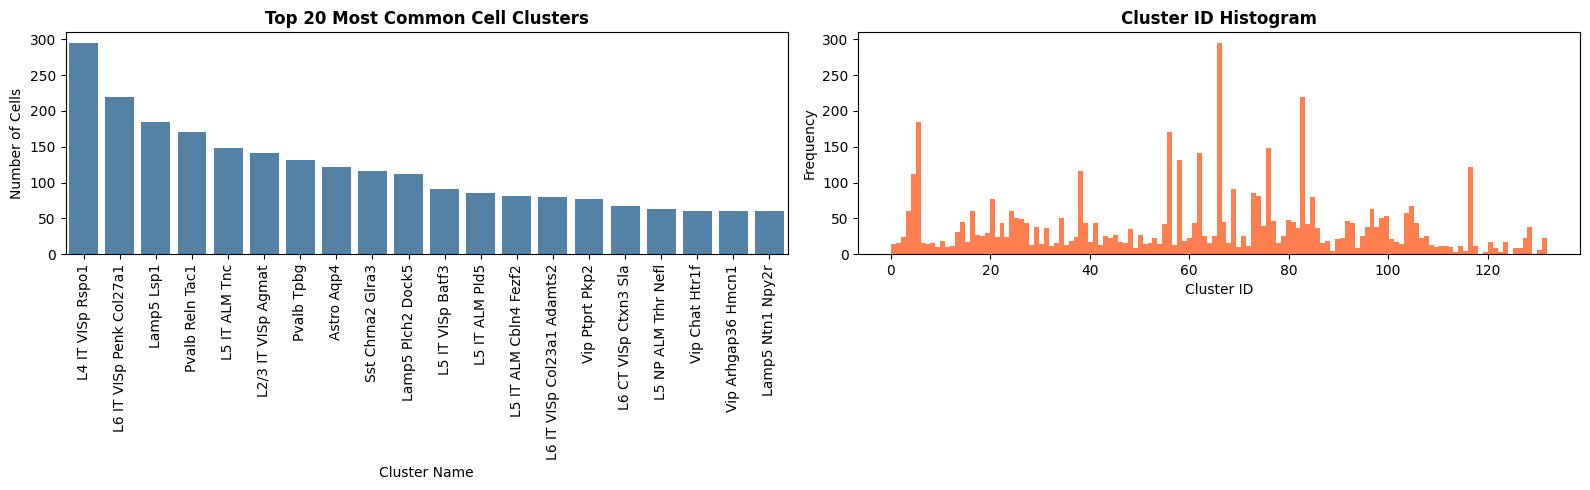

In [17]:
# ── Cluster (cell type) distribution ──────────────────────────────────────
cluster_counts = pd.Series(clusters).value_counts().sort_index()

# Print the top 10 most common cell types
print("Top 10 most common cell types:")
for cid, cnt in cluster_counts.sort_values(ascending=False).iloc[:10].items():
    print(f"  [{cid:3d}] {cluster_names[cid]:<40s}  {cnt:4d} cells")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prepare data for the bar chart with cluster names
top_20_clusters = cluster_counts.sort_values(ascending=False).iloc[:20]
top_20_cluster_names = [cluster_names[cid] for cid in top_20_clusters.index]

# Bar chart: top 20 clusters by cell count using seaborn
sns.barplot(x=top_20_cluster_names, y=top_20_clusters.values, ax=axes[0], color="steelblue")
axes[0].set_title("Top 20 Most Common Cell Clusters", fontweight="bold")
axes[0].set_xlabel("Cluster Name")
axes[0].set_ylabel("Number of Cells")
axes[0].tick_params(axis="x", rotation=90)

# Histogram: how many cells belong to each cluster ID
pd.Series(clusters).plot(
    kind="hist", bins=len(np.unique(clusters)), ax=axes[1], color="coral")
axes[1].set_title("Cluster ID Histogram", fontweight="bold")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

distribution of cell types


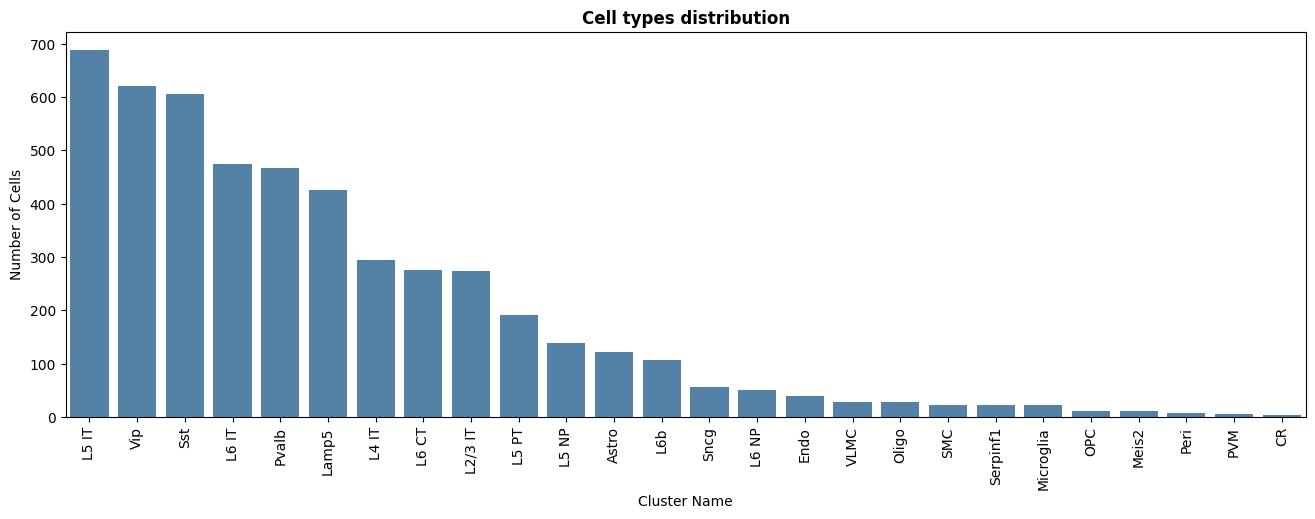

In [38]:
data, cell_type_to_cell_label, cell_type_to_cell_label_ = get_data_and_labels()
print("distribution of cell types")
df_clusters = pd.Series(data["cell_types"])
count_values = df_clusters.value_counts().sort_values(ascending=False)
clusters_names = [cell_type_to_cell_label_[cid] for cid in count_values.index]
fig, axes = plt.subplots(1, 1, figsize=(16, 5))
axes=[axes]
sns.barplot(x=clusters_names, y=count_values.values, ax=axes[0], color="steelblue")
axes[0].set_title("Cell types distribution", fontweight="bold")
axes[0].set_xlabel("Cluster Name")
axes[0].set_ylabel("Number of Cells")
axes[0].tick_params(axis="x", rotation=90)
plt.show()

/tmp/ipykernel_9938/983213716.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="names", y="count", data=my_df, palette="viridis")


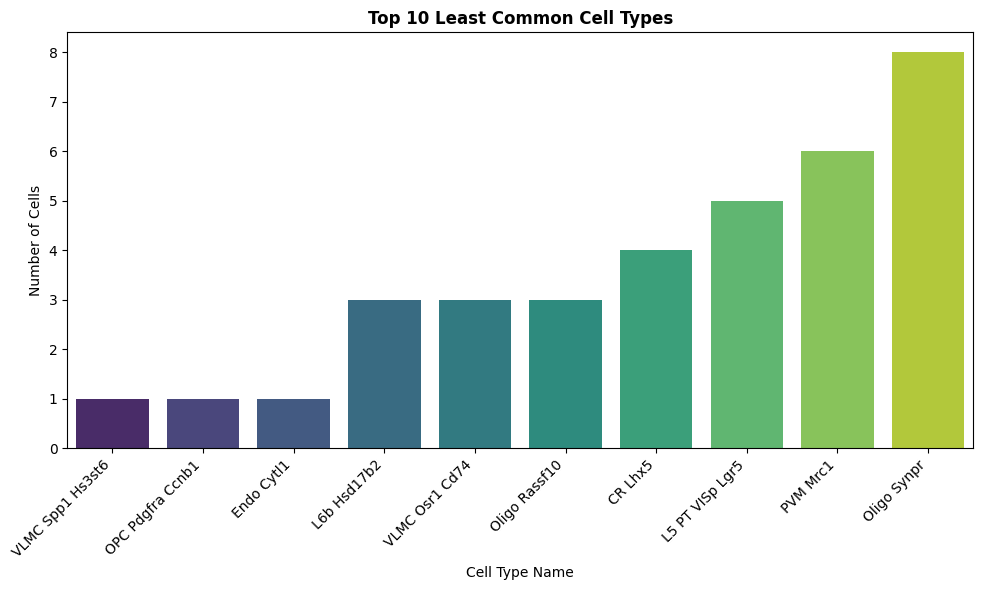

In [18]:
# ── Bottom 10 clusters by cell count (rarest cell types) ──────────────────
cell_types = list(cluster_counts.sort_values(ascending=True).head(10).index)
names      = [cluster_names[cid] for cid in cell_types]
my_df      = pd.DataFrame(cluster_counts.sort_values(ascending=True).head(10))
my_df["names"] = names
my_df.head(10)

# Plot the bottom 10 least common cell types
plt.figure(figsize=(10, 6))
sns.barplot(x="names", y="count", data=my_df, palette="viridis")
plt.title("Top 10 Least Common Cell Types", fontweight="bold")
plt.xlabel("Cell Type Name")
plt.ylabel("Number of Cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

 Brain_Area  Number_of_Cells  Percentage (%)
          0             3458           69.16
          1             1542           30.84

  Area 0: 120 unique cell types
  Area 1: 42 unique cell types


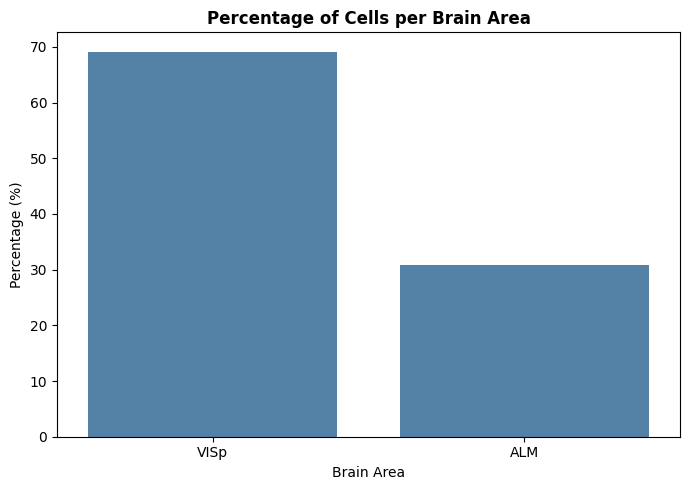

In [19]:
# ── Brain area distribution ────────────────────────────────────────────────
area_counts = pd.Series(areas).value_counts().sort_index()

# Summary table: number of cells and percentage per brain area
area_summary = pd.DataFrame({
    "Brain_Area"     : area_counts.index,
    "Number_of_Cells": area_counts.values,
    "Percentage (%)": (area_counts.values / n_cells * 100).round(2),
})
print(area_summary.to_string(index=False))

# Count how many unique cell types appear in each brain area
print()
for area_id in np.unique(areas):
    n_unique = counts_df[counts_df["Area"] == area_id]["Cluster"].nunique()
    print(f"  Area {area_id}: {n_unique} unique cell types")

# Define the custom brain area names
brain_area_names = {0: "VISp", 1: "ALM"}

# Prepare data for the seaborn barplot using percentages for normalization
plot_df = pd.DataFrame({
    "Brain_Area_Name": area_counts.index.map(brain_area_names),
    "Percentage": (area_counts.values / n_cells * 100).round(2)
})

fig, ax = plt.subplots(1, 1, figsize=(7, 5)) # Single subplot

# Use seaborn for the bar plot of percentage of cells per area
sns.barplot(x="Brain_Area_Name", y="Percentage", data=plot_df, ax=ax, color="steelblue")
ax.set_title("Percentage of Cells per Brain Area", fontweight="bold")
ax.set_xlabel("Brain Area")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", rotation=0) # No rotation needed for 2 labels

plt.tight_layout()
plt.show()

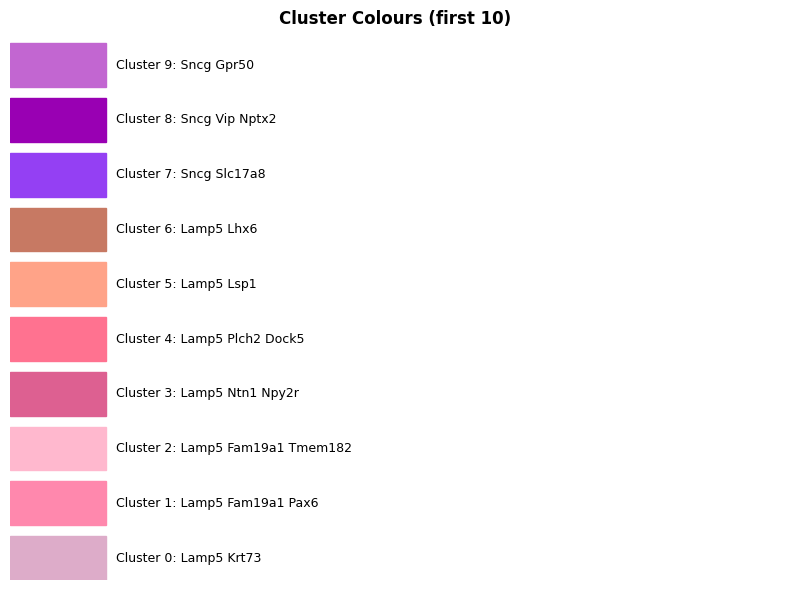

In [20]:
# ── Colour swatch for the first 10 clusters ───────────────────────────────
# Provides a quick visual reference for which colour represents which cell type
fig, ax = plt.subplots(figsize=(8, 6))
show_clusters = np.unique(clusters)[:10]

for i, cid in enumerate(show_clusters):
    ax.add_patch(mpatches.Rectangle((0, i), 1, 0.8, color=cluster_colors[cid]))
    ax.text(1.1, i + 0.4, f"Cluster {cid}: {cluster_names[cid]}", va="center", fontsize=9)

ax.set_xlim(0, 8)
ax.set_ylim(0, len(show_clusters))
ax.axis("off")
ax.set_title("Cluster Colours (first 10)", fontweight="bold")
plt.tight_layout()
plt.show()


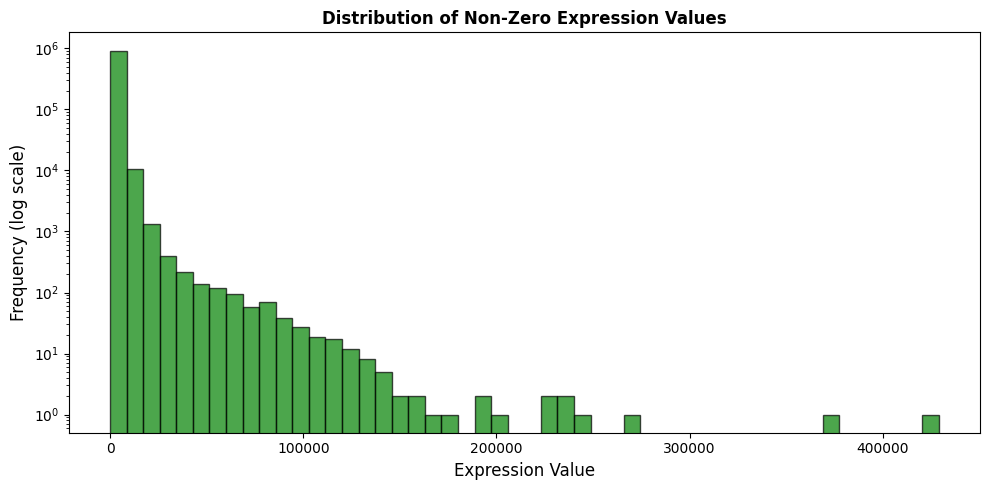

Non-zero values: 937,979  |  max = 428848  |  mean = 1277.70


In [21]:
# ── Distribution of non-zero expression values ────────────────────────────
# Shows the spread of actual read counts (excluding the many zeros)
non_zero = counts_array[counts_array > 0]

plt.figure(figsize=(10, 5))
plt.hist(non_zero, bins=50, color="green", alpha=0.7, edgecolor="black")
plt.yscale("log")  # log scale because most genes have low expression
plt.xlabel("Expression Value", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.title("Distribution of Non-Zero Expression Values", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Non-zero values: {len(non_zero):,}  |  max = {non_zero.max():.0f}  |  mean = {non_zero.mean():.2f}")


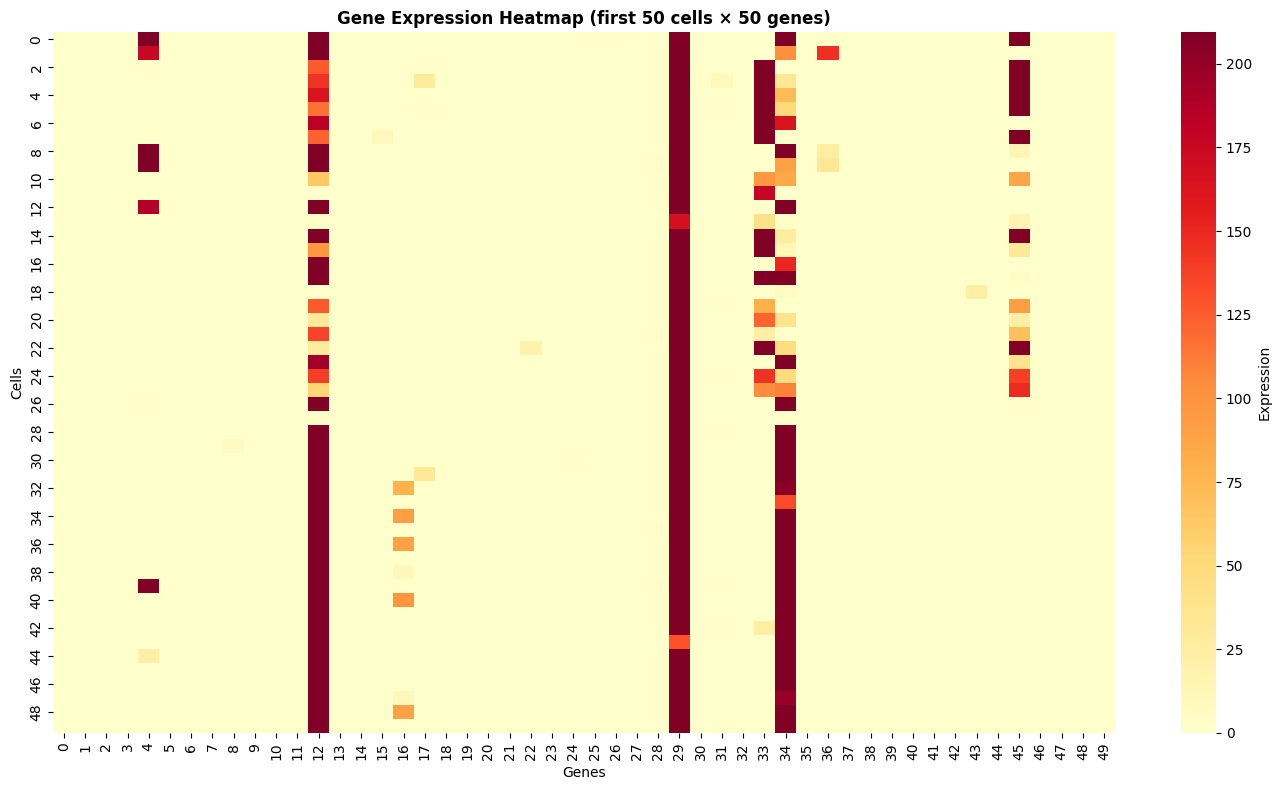

In [22]:
# ── Expression heatmap — first 50 cells × 50 genes ───────────────────────
# Gives a quick visual sense of the sparsity and variation in the data
plt.figure(figsize=(14, 8))
sns.heatmap(
    counts_array[:50, :50],
    cmap="YlOrRd",
    vmin=0,
    vmax=np.percentile(counts_array[:50, :50], 95),  # cap at 95th percentile to avoid outlier dominance
    cbar_kws={"label": "Expression"},
)
plt.title("Gene Expression Heatmap (first 50 cells × 50 genes)", fontweight="bold")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.tight_layout()
plt.show()


In [23]:
# ── Cell type × brain area breakdown ─────────────────────────────────────
# Shows which cell types appear in each brain area
cell_info = pd.DataFrame({
    "Cluster_Name": [cluster_names[c] for c in clusters],
    "Brain_Area"  : areas,
})

# Area 1
mask_1 = cell_info["Brain_Area"] == 1
area_cluster_summary_1 = cell_info[mask_1].groupby(["Brain_Area", "Cluster_Name"]).size()
print("Cell types per brain area — Area 1 (first 20 rows):")
print(area_cluster_summary_1.head(20))

# Area 0
mask_0 = cell_info["Brain_Area"] == 0
area_cluster_summary_0 = cell_info[mask_0].groupby(["Brain_Area", "Cluster_Name"]).size()
print()
print("Cell types per brain area — Area 0 (first 20 rows):")
print(area_cluster_summary_0.head(20))


Cell types per brain area — Area 1 (first 20 rows):
Brain_Area  Cluster_Name            
1           L2/3 IT VISp Adamts2         41
            L2/3 IT VISp Agmat          134
            L2/3 IT VISp Rrad            21
            L4 IT VISp Rspo1            292
            L5 IT VISp Batf3             86
            L5 IT VISp Col27a1           20
            L5 IT VISp Col6a1 Fezf2       8
            L5 IT VISp Hsd11b1 Endou     45
            L5 IT VISp Whrn Tox2         14
            L5 NP VISp Trhr Cpne7        32
            L5 NP VISp Trhr Met          37
            L5 PT VISp C1ql2 Cdh13       23
            L5 PT VISp C1ql2 Ptgfr       21
            L5 PT VISp Chrna6            19
            L5 PT VISp Krt80             46
            L5 PT VISp Lgr5               5
            L6 CT VISp Ctxn3 Brinp3      58
            L6 CT VISp Ctxn3 Sla         66
            L6 CT VISp Gpr139            13
            L6 CT VISp Krt80 Sla         41
dtype: int64

Cell types per br

---
## Section 4 — Normalization

We compare three normalization strategies and use PCA to evaluate how well each separates cell types.

| Method | Steps |
|--------|-------|
| **Method 1** | Z-score only |
| **Method 2** | log(x+1) → z-score |
| **Method 3** | CPM → log2(CPM+1) → z-score |


In [24]:
# ── Shared helper: run PCA and print a variance summary ───────────────────
def run_pca(X, n_components=10, label=""):
    """
    Fit PCA on X and print how much variance the first 10 PCs explain.

    Parameters
    ----------
    X            : np.ndarray, normalized expression matrix
    n_components : int, number of principal components to compute
    label        : str, displayed in the printed summary

    Returns
    -------
    pca    : fitted PCA object
    result : transformed data, shape (n_cells, n_components)
    """
    pca    = PCA(n_components=n_components, svd_solver="randomized", random_state=42)
    result = pca.fit_transform(X)
    vexp   = pca.explained_variance_ratio_
    print(f"[{label}]  PC1={vexp[0]*100:.2f}%  PC2={vexp[1]*100:.2f}%  "
          f"PC1+PC2={sum(vexp[:2])*100:.2f}%  first10={sum(vexp)*100:.2f}%")
    return pca, result


In [25]:
# ── Method 1: Z-score only ────────────────────────────────────────────────
# Standardize each gene to zero mean and unit variance across all cells
scaler_zscore  = StandardScaler()
counts_zscore  = scaler_zscore.fit_transform(counts_array)
pca_m1, res_m1 = run_pca(counts_zscore, label="Method 1 – Z-score only")


[Method 1 – Z-score only]  PC1=9.21%  PC2=6.39%  PC1+PC2=15.61%  first10=40.14%


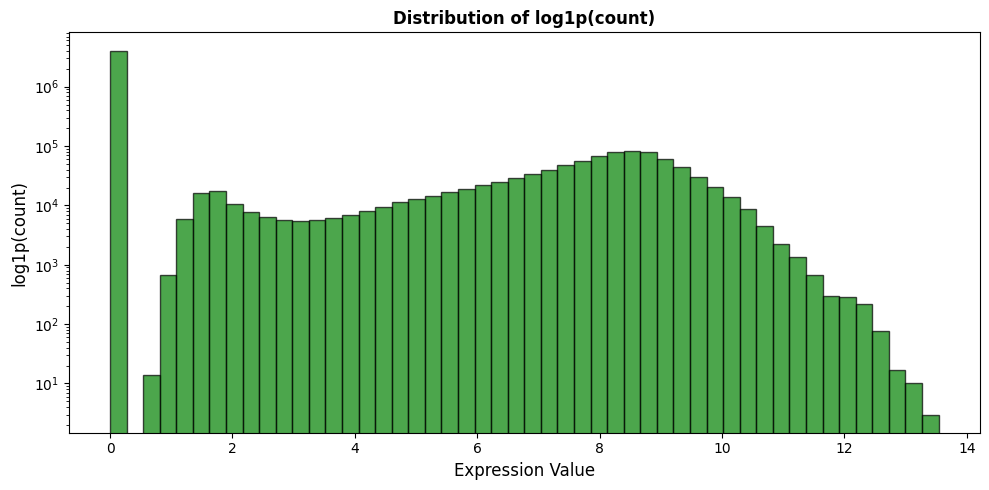

log1p: 5,000,000  |  max = 14  |  mean = 1.38


In [26]:
# ── Distribution of non-zero expression values ────────────────────────────
# Shows the spread of actual read counts (excluding the many zeros)
cpm = counts_array/counts_array.sum(axis=1, keepdims=True)*1e6
x = counts_array.copy()
log1p_ = np.log1p(cpm).flatten()
#log1p_ = (log1p_-log1p_.mean())/(log1p_.std()+1e-5)

plt.figure(figsize=(10, 5))
plt.hist(log1p_,bins = 50,color="green", alpha=0.7, edgecolor="black")
plt.xlabel("Expression Value", fontsize=12)
plt.ylabel("log1p(count)", fontsize=12)
plt.title("Distribution of log1p(count)", fontweight="bold")
plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"log1p: {len(log1p_):,}  |  max = {log1p_.max():.0f}  |  mean = {log1p_.mean():.2f}")


In [27]:
# ── Method 2: log(x+1) followed by z-score ────────────────────────────────
# log1p compresses the wide dynamic range of count data before scaling
counts_log     = np.log1p(counts_array)
scaler_log     = StandardScaler()
counts_lognorm = scaler_log.fit_transform(counts_log)
pca_m2, res_m2 = run_pca(counts_lognorm, label="Method 2 – log(x+1) + z-score")


[Method 2 – log(x+1) + z-score]  PC1=16.10%  PC2=7.88%  PC1+PC2=23.98%  first10=49.08%


In [28]:
# ── Method 3: CPM → log2(CPM+1) → z-score ────────────────────────────────
# CPM (counts per million) corrects for differences in library size across cells.
# log2 transformation then compresses the range, and z-score standardizes.

def lognormalize_counts(tasic_dict):
    """
    Apply CPM normalization followed by log2 transformation.

    Steps:
      1. Divide each cell's counts by its total library size and multiply by 1e6
         → gives Counts Per Million (CPM): comparable across cells
      2. Apply log2(CPM + 1) to compress the dynamic range
         → the +1 avoids log(0)

    The result is stored in tasic_dict['logCPM'] and the dict is returned.
    """
    counts = tasic_dict["counts"]
    if scipy.sparse.issparse(counts):
        counts = counts.toarray()
    elif isinstance(counts, np.matrix):
        counts = np.asarray(counts)

    libsizes             = counts.sum(axis=1, keepdims=True)  # total counts per cell
    CPM                  = counts / libsizes * 1e6            # normalize to CPM
    logCPM               = np.log2(CPM + 1)                  # log2 transform
    tasic_dict["logCPM"] = logCPM
    return tasic_dict

# Apply normalization and scale
data           = lognormalize_counts(data)
logCPM         = data["logCPM"]
scaler_cpm     = StandardScaler()
logCPM_scaled  = scaler_cpm.fit_transform(logCPM)
pca_m3, res_m3 = run_pca(logCPM_scaled, label="Method 3 – CPM + log2 + z-score")


[Method 3 – CPM + log2 + z-score]  PC1=16.08%  PC2=7.51%  PC1+PC2=23.59%  first10=47.34%


In [29]:
clusters

array([ 93,  72,   1, ..., 127, 127, 127])

---
## Section 5 — Dimensionality Reduction: PCA & t-SNE

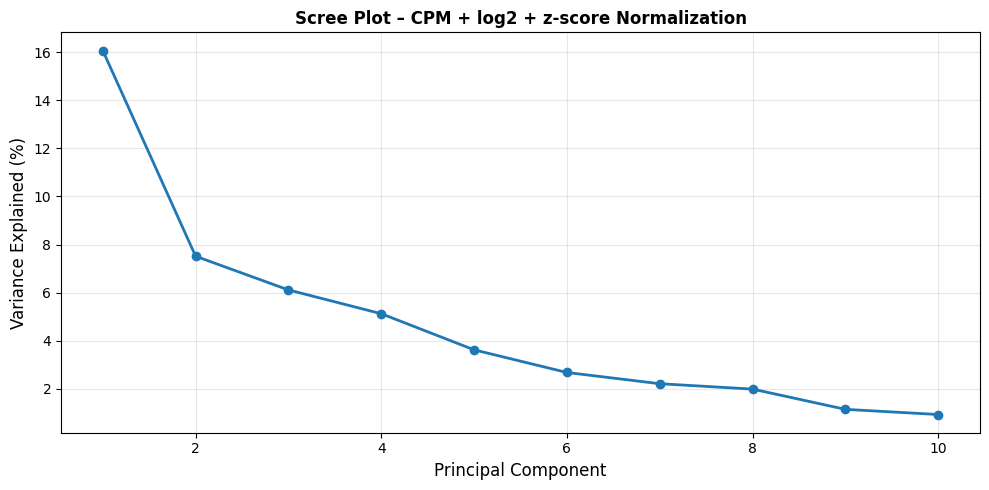

In [ ]:
# ── Scree plot: variance explained by each principal component ────────────
# Helps decide how many PCs to retain before running t-SNE
vexp = pca_m3.explained_variance_ratio_

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(vexp) + 1), vexp * 100, marker="o", linewidth=2)
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Variance Explained (%)", fontsize=12)
plt.title("Scree Plot – CPM + log2 + z-score Normalization", fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
data_path = "/content/drive/MyDrive/tasic_subset_1kselectedB.pickle"

In [ ]:
!cp -r /content/drive/MyDrive/drive/saves_proj/* .

In [ ]:
from tsimcne2 import *
import matplotlib.patheffects as effects
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    f1_score,
)

In [ ]:
def get_data_and_labels(data_path=data_path):

  data = load_tasic_data(data_path)
  cell_df=pd.read_csv("cell_types.csv")
  subcell_to_cell_type = dict()

  for row in cell_df.iterrows():
    sub_cell_type= row[1]["subtype"]
    cell_type = row[1]["cell_types"]
    if sub_cell_type not in subcell_to_cell_type:
      subcell_to_cell_type[sub_cell_type] = cell_type
  uniques_cell_types_df = cell_df["cell_types"].value_counts()

  cell_labels = list(range(len(uniques_cell_types_df)))
  cell_type_to_cell_label = dict()
  for cell_type in uniques_cell_types_df.index:
    cell_type_to_cell_label[cell_type] = cell_labels[uniques_cell_types_df.index.get_loc(cell_type)]

  data["cell_types"] = [cell_type_to_cell_label[subcell_to_cell_type[data["clusterNames"][el].strip()]] for el in data["clusters"]]

  data["cell_types"]
  cell_type_to_cell_label_ = {v:k for k,v in cell_type_to_cell_label.items()}
  return data, cell_type_to_cell_label, cell_type_to_cell_label_

data , cell_type_to_cell_label, cell_type_to_cell_label_ = get_data_and_labels()

In [ ]:
from tasic_ssl import evaluate_knn

knn_pca_m3 = evaluate_knn(res_m3,clusters)

[kNN probe]   k=1      acc=0.4500  macro-F1=0.3848
[kNN probe]   k=5      acc=0.4980  macro-F1=0.3683
[kNN probe]   k=15     acc=0.5240  macro-F1=0.3743


In [ ]:
evaluate_clustering(res_m3,clusters)

[Clustering]  K-Means    ARI=0.2688  NMI=0.6624


{'ari': 0.2688295227804595, 'nmi': np.float64(0.662393568625277)}

In [ ]:
data , _, _ = get_data_and_labels(data_path)
knn_pca_m3_cell_types = evaluate_knn(res_m3,data["cell_types"])

[kNN probe]   k=1      acc=0.8090  macro-F1=0.8702
[kNN probe]   k=5      acc=0.8450  macro-F1=0.7607
[kNN probe]   k=15     acc=0.8380  macro-F1=0.7064


In [ ]:
evaluate_clustering(res_m3,data["cell_types"])

[Clustering]  K-Means    ARI=0.4370  NMI=0.7276


{'ari': 0.43698216704338855, 'nmi': np.float64(0.7276272971571325)}

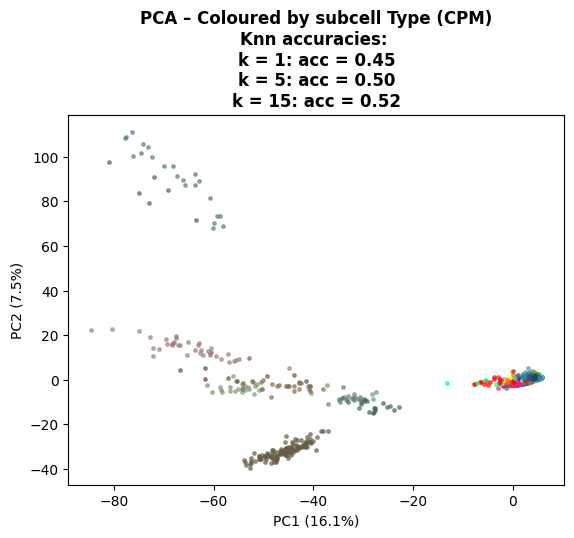

In [ ]:
# ── PCA coloured by brain area (to check area-specific structure) ─────────
def scatter_pca(ax, pca_result, pca_obj, title, clusters):
    """Plot a 2D PCA scatter on the given axis, coloured by cell type."""
    vexp         = pca_obj.explained_variance_ratio_
    for cid in np.unique(clusters):
        mask = clusters == cid
        ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
                   c=cluster_colors[cid], s=6, alpha=0.6)
    ax.set_xlabel(f"PC1 ({vexp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({vexp[1]*100:.1f}%)")
    ax.set_title(title, fontweight="bold")
    #ax.legend(title=f"SubCell Type", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')

def scatter_by_area(ax, pca_result, pca_obj):
    """Plot a 2D PCA scatter on the given axis, coloured by brain area."""
    vexp         = pca_obj.explained_variance_ratio_
    unique_areas = np.unique(areas)
    area_colors  = plt.cm.Set3(np.linspace(0, 1, len(unique_areas)))
    for i, area in enumerate(unique_areas):
        mask = areas == area
        ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
                   c=[area_colors[i]], s=6, alpha=0.6, label=str(area))
    ax.set_xlabel(f"PC1 ({vexp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({vexp[1]*100:.1f}%)")
    ax.legend(title="Area", markerscale=2)

fig, ax = plt.subplots()
metrics_str = "\n".join(["Knn accuracies: " ]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_pca_m3.items()])
scatter_pca(ax, res_m3, pca_m3, f"PCA – Coloured by subcell Type (CPM)\n{metrics_str}",clusters)
#remove the axes[0] axis(set it off)
#ax.axis("off")
plt.show()

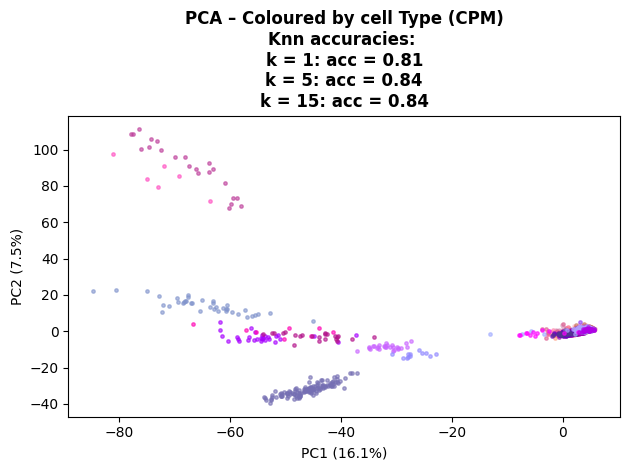

In [ ]:
fig, ax = plt.subplots()
metrics_cell_type_str = "\n".join(["Knn accuracies: " ]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_pca_m3_cell_types.items()])
#print(metrics_cell_type_str)
scatter_pca(ax, res_m3, pca_m3, f"PCA – Coloured by cell Type (CPM)\n{metrics_cell_type_str}",data["cell_types"])
#axes[1].set_visible(False)
#ax.axis("Off")
plt.tight_layout()
plt.show()

In [ ]:
# ── t-SNE baseline: simple run on CPM + log2 + z-score data ──────────────
# This is a basic t-SNE with default settings — used as a reference
print("Running baseline t-SNE on CPM + log2 + z-score data...")
tsne        = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(logCPM_scaled)
print(f"t-SNE complete. Shape: {tsne_result.shape}")


Running baseline t-SNE on CPM + log2 + z-score data...
t-SNE complete. Shape: (5000, 2)


In [ ]:
np.save("tasic_tsne.npy",tsne_result)

In [ ]:
tsne_result = np.load("tasic_tsne.npy")

In [ ]:
data, _,_ = get_data_and_labels()

In [ ]:
knn_tsne = evaluate_knn(tsne_result,clusters)
metrics_str = "\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_tsne.items()])

[kNN probe]   k=1      acc=0.7240  macro-F1=0.6297
[kNN probe]   k=5      acc=0.7430  macro-F1=0.6330
[kNN probe]   k=15     acc=0.7370  macro-F1=0.5398


In [ ]:
knn_tsne_cell_type = evaluate_knn(tsne_result, data["cell_types"])
metrics_cell_type_str = "\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_tsne_cell_type.items()])

[kNN probe]   k=1      acc=0.9700  macro-F1=0.9497
[kNN probe]   k=5      acc=0.9720  macro-F1=0.8939
[kNN probe]   k=15     acc=0.9680  macro-F1=0.7924


In [ ]:
evaluate_clustering(tsne_result, clusters)

[Clustering]  K-Means    ARI=0.3538  NMI=0.7693


{'ari': 0.3538153967984413, 'nmi': np.float64(0.7693202194660145)}

In [ ]:
evaluate_clustering(tsne_result, data["cell_types"])

[Clustering]  K-Means    ARI=0.5933  NMI=0.8313


{'ari': 0.5932768614744272, 'nmi': np.float64(0.831270384651992)}

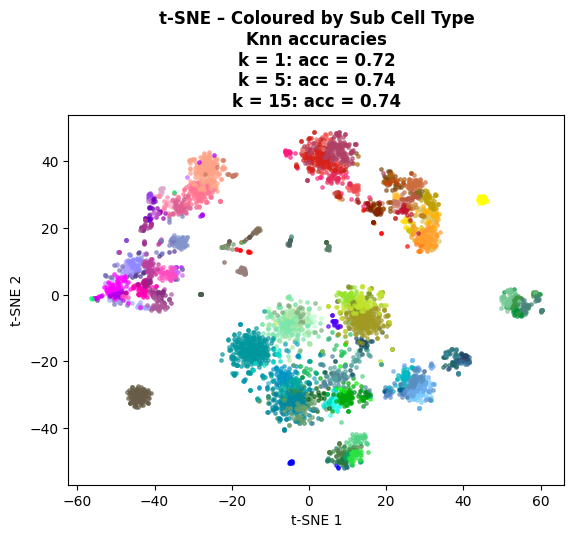

In [ ]:
# ── t-SNE scatter: side by side coloured by cell type and by brain area ───
fig, ax = plt.subplots()

# Coloured by cluster (cell type)
for cid in np.unique(clusters):
    mask = clusters == cid
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=cluster_colors[cid], s=6, alpha=0.6)
ax.set_title(f"t-SNE – Coloured by Sub Cell Type\n{metrics_str}", fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
#ax.axis("Off")
plt.show()


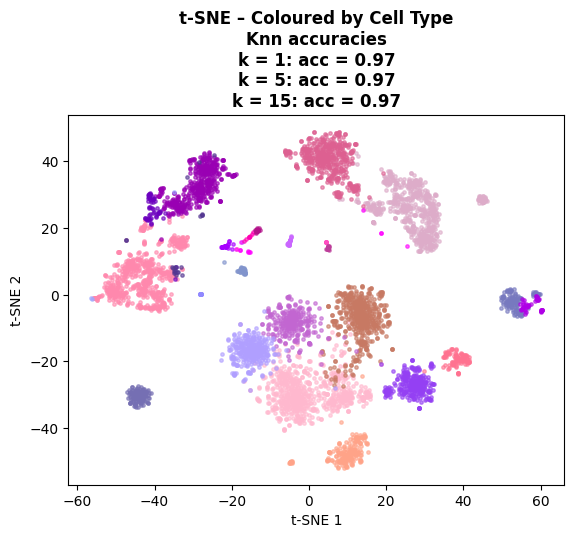

In [ ]:
# ── t-SNE scatter: side by side coloured by cell type and by brain area ───
fig, ax = plt.subplots()

# Coloured by cluster (cell type)
for cid in np.unique(data["cell_types"]):
    mask =data["cell_types"]== cid
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=cluster_colors[cid], s=6, alpha=0.6)
ax.set_title(f"t-SNE – Coloured by Cell Type\n{metrics_cell_type_str}", fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
#ax.axis("Off")
plt.show()

### Improved t-SNE — Kobak & Berens (2019) Protocol

The recommended protocol for high-quality t-SNE on scRNA-seq data:
1. Reduce to **50 PCA components** first to remove noise
2. Use **PCA initialisation** instead of random
3. Set **learning rate = n/12** (where n = number of cells)
4. Run with both **small perplexity (30)** and **large perplexity (n/100)** — multi-scale


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

n_cells = logCPM_scaled.shape[0]
print(f"Number of cells       : {n_cells}")
print(f"Recommended LR (n/12) : {n_cells/12:.0f}")
print(f"Large perplexity (n/100): {n_cells/100:.0f}")

# Step 1: Reduce to 50 PCs first — removes noise and speeds up t-SNE
pca_50    = PCA(n_components=50, random_state=42)
data_50pc = pca_50.fit_transform(logCPM_scaled)
print(f"\nReduced to 50 PCs. Shape: {data_50pc.shape}")


Number of cells       : 5000
Recommended LR (n/12) : 417
Large perplexity (n/100): 50

Reduced to 50 PCs. Shape: (5000, 50)


In [ ]:
# ── t-SNE with small perplexity (local structure) ─────────────────────────
tsne_small = TSNE(
    n_components=2,
    init='pca',                  # PCA initialisation — more stable than random
    learning_rate=n_cells / 12, # high learning rate recommended for scRNA-seq
    perplexity=30,               # captures local neighbourhood structure
    max_iter=1000,
    random_state=42
)
tsne_small_result = tsne_small.fit_transform(data_50pc)
print("t-SNE (small perplexity, p=30) complete.")
np.save("tasic_tsne_small.npy", tsne_small_result)


t-SNE (small perplexity, p=30) complete.


In [ ]:
tsne_small_result = np.load("tasic_tsne_small.npy")

In [ ]:
evaluate_clustering(tsne_small_result, clusters)

[Clustering]  K-Means    ARI=0.3845  NMI=0.8025


{'ari': 0.3845357198092701, 'nmi': np.float64(0.802522185881297)}

In [ ]:
evaluate_clustering(tsne_small_result, data["cell_types"])

[Clustering]  K-Means    ARI=0.5754  NMI=0.8397


{'ari': 0.5753834439368163, 'nmi': np.float64(0.8396511142528992)}

In [ ]:
# ── t-SNE with large perplexity (global structure) ────────────────────────
# A higher perplexity considers larger neighbourhoods — better for global layout
large_perplexity = n_cells / 100  # = 50 for 5000 cells

tsne_large = TSNE(
    n_components=2,
    init='pca',
    learning_rate=n_cells / 12,
    perplexity=large_perplexity,
    max_iter=1000,
    random_state=42
)
tsne_large_result = tsne_large.fit_transform(data_50pc)
print("t-SNE (large perplexity, p=50) complete.")
np.save("tasic_tsne_large.npy", tsne_large_result)


t-SNE (large perplexity, p=50) complete.


In [ ]:
tsne_large_result = np.load("tasic_tsne_large.npy")

In [ ]:
evaluate_clustering(tsne_large_result, clusters)

[Clustering]  K-Means    ARI=0.3842  NMI=0.8017


{'ari': 0.3841588956218211, 'nmi': np.float64(0.8017206036254908)}

In [ ]:
evaluate_clustering(tsne_large_result, data["cell_types"])

[Clustering]  K-Means    ARI=0.6025  NMI=0.8460


{'ari': 0.602541744152516, 'nmi': np.float64(0.8460206332116977)}

In [ ]:
# ── True multi-scale t-SNE using openTSNE ────────────────────────────────
# Multi-scale t-SNE (Kobak & Berens, 2019) combines both perplexities
# simultaneously to capture local AND global structure.
# scikit-learn does not support this natively — we use openTSNE instead.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "openTSNE", "-q"])

from openTSNE import TSNE as openTSNE

tsne_proper = openTSNE(
    n_components=2,
    initialization='pca',             # PCA initialisation
    learning_rate=n_cells / 12,       # high learning rate
    perplexity=[30, n_cells / 100],   # multi-scale: local + global simultaneously
    n_iter=1000,
    random_state=42,
    verbose=True
)
tsne_proper_result = tsne_proper.fit(data_50pc)
np.save("tasic_tsne_proper.npy", tsne_proper_result)
print("\nTrue multi-scale t-SNE complete.")


--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, learning_rate=416.6666666666667, n_iter=1000,
     perplexity=[30, 50.0], random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 150 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 4.21 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 1.64 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=416.67 for 250 iterations...
Iteration   50, KL divergence 3.0091, 50 iterations in 1.7523 sec
Iteration  100, KL divergence 2.6507, 50 iterations in 2.0172 sec
Iteration  150, KL divergence 2.5571, 50 iterations in 2.6116 sec
Iteration  200, KL divergence 2.5142, 50 iterations in 1.7640 sec
Iteration  250, KL divergence 2.4874, 50 iterations in 1.5292 sec
   --> Time ela

In [ ]:
tsne_proper_result = np.load("tasic_tsne_proper.npy")

In [ ]:
evaluate_clustering(tsne_proper_result, clusters)

[Clustering]  K-Means    ARI=0.3950  NMI=0.8045


{'ari': 0.3949967303368699, 'nmi': np.float64(0.8045438798424086)}

In [ ]:
evaluate_clustering(tsne_proper_result, data["cell_types"])

[Clustering]  K-Means    ARI=0.5801  NMI=0.8406


{'ari': 0.5801095057703787, 'nmi': np.float64(0.8406004537497709)}

[kNN probe]   k=1      acc=0.7240  macro-F1=0.6297
[kNN probe]   k=5      acc=0.7430  macro-F1=0.6330
[kNN probe]   k=15     acc=0.7370  macro-F1=0.5398
[kNN probe]   k=1      acc=0.7690  macro-F1=0.6762
[kNN probe]   k=5      acc=0.7750  macro-F1=0.6651
[kNN probe]   k=15     acc=0.7650  macro-F1=0.6011
[kNN probe]   k=1      acc=0.7630  macro-F1=0.6663
[kNN probe]   k=5      acc=0.7670  macro-F1=0.6528
[kNN probe]   k=15     acc=0.7700  macro-F1=0.5928
[kNN probe]   k=1      acc=0.7720  macro-F1=0.6766
[kNN probe]   k=5      acc=0.7740  macro-F1=0.6671
[kNN probe]   k=15     acc=0.7580  macro-F1=0.5841


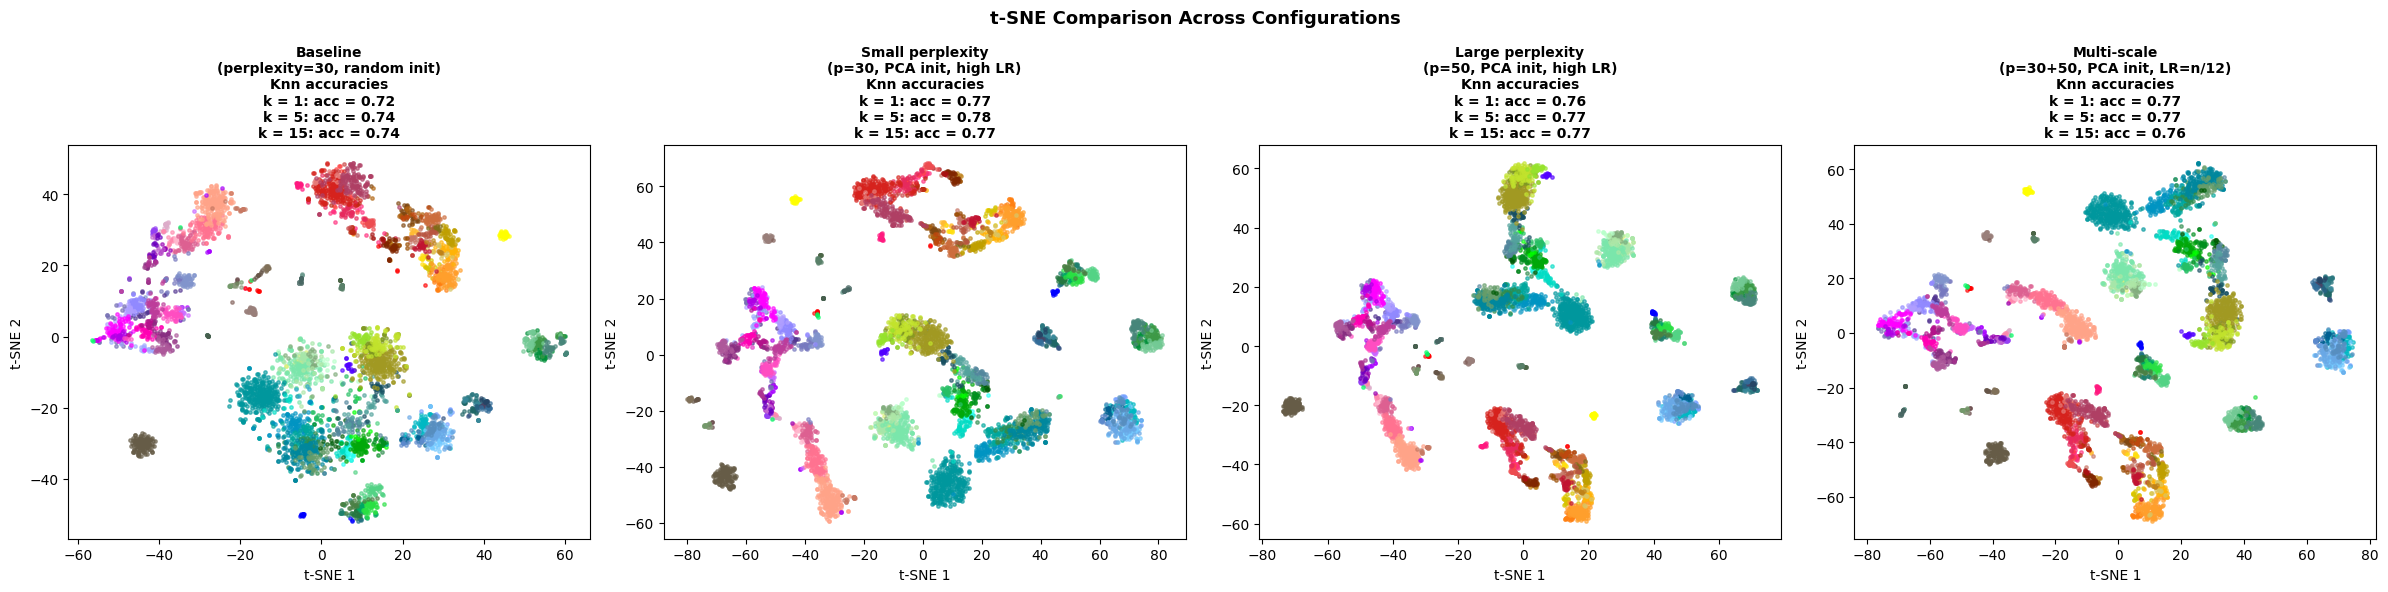

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

results = [
    (tsne_result,               "Baseline\n(perplexity=30, random init)"),
    (tsne_small_result,         "Small perplexity\n(p=30, PCA init, high LR)"),
    (tsne_large_result,         "Large perplexity\n(p=50, PCA init, high LR)"),
    (np.array(tsne_proper_result), "Multi-scale\n(p=30+50, PCA init, LR=n/12)"),
]
knn_results = [evaluate_knn(result, clusters) for result, _ in results];
metrics_str = ["\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in res.items()]) for res in knn_results]
for ax, (result, title), metric in zip(axes, results, metrics_str):
    for cid in np.unique(data['clusters']):
        mask = data['clusters'] == cid
        ax.scatter(result[mask, 0], result[mask, 1],
                   c=data['clusterColors'][cid], s=6, alpha=0.6)
    ax.set_title(f"{title}\n{metric}", fontsize=10, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    #ax.axis("Off")

plt.suptitle("t-SNE Comparison Across Configurations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
data, _,_ = get_data_and_labels()

[kNN probe]   k=1      acc=0.9700  macro-F1=0.9497
[kNN probe]   k=5      acc=0.9720  macro-F1=0.8939
[kNN probe]   k=15     acc=0.9680  macro-F1=0.7924
[kNN probe]   k=1      acc=0.9860  macro-F1=0.9429
[kNN probe]   k=5      acc=0.9830  macro-F1=0.9121
[kNN probe]   k=15     acc=0.9750  macro-F1=0.8098
[kNN probe]   k=1      acc=0.9840  macro-F1=0.9363
[kNN probe]   k=5      acc=0.9830  macro-F1=0.9062
[kNN probe]   k=15     acc=0.9750  macro-F1=0.8083
[kNN probe]   k=1      acc=0.9870  macro-F1=0.9435
[kNN probe]   k=5      acc=0.9830  macro-F1=0.9123
[kNN probe]   k=15     acc=0.9750  macro-F1=0.8101


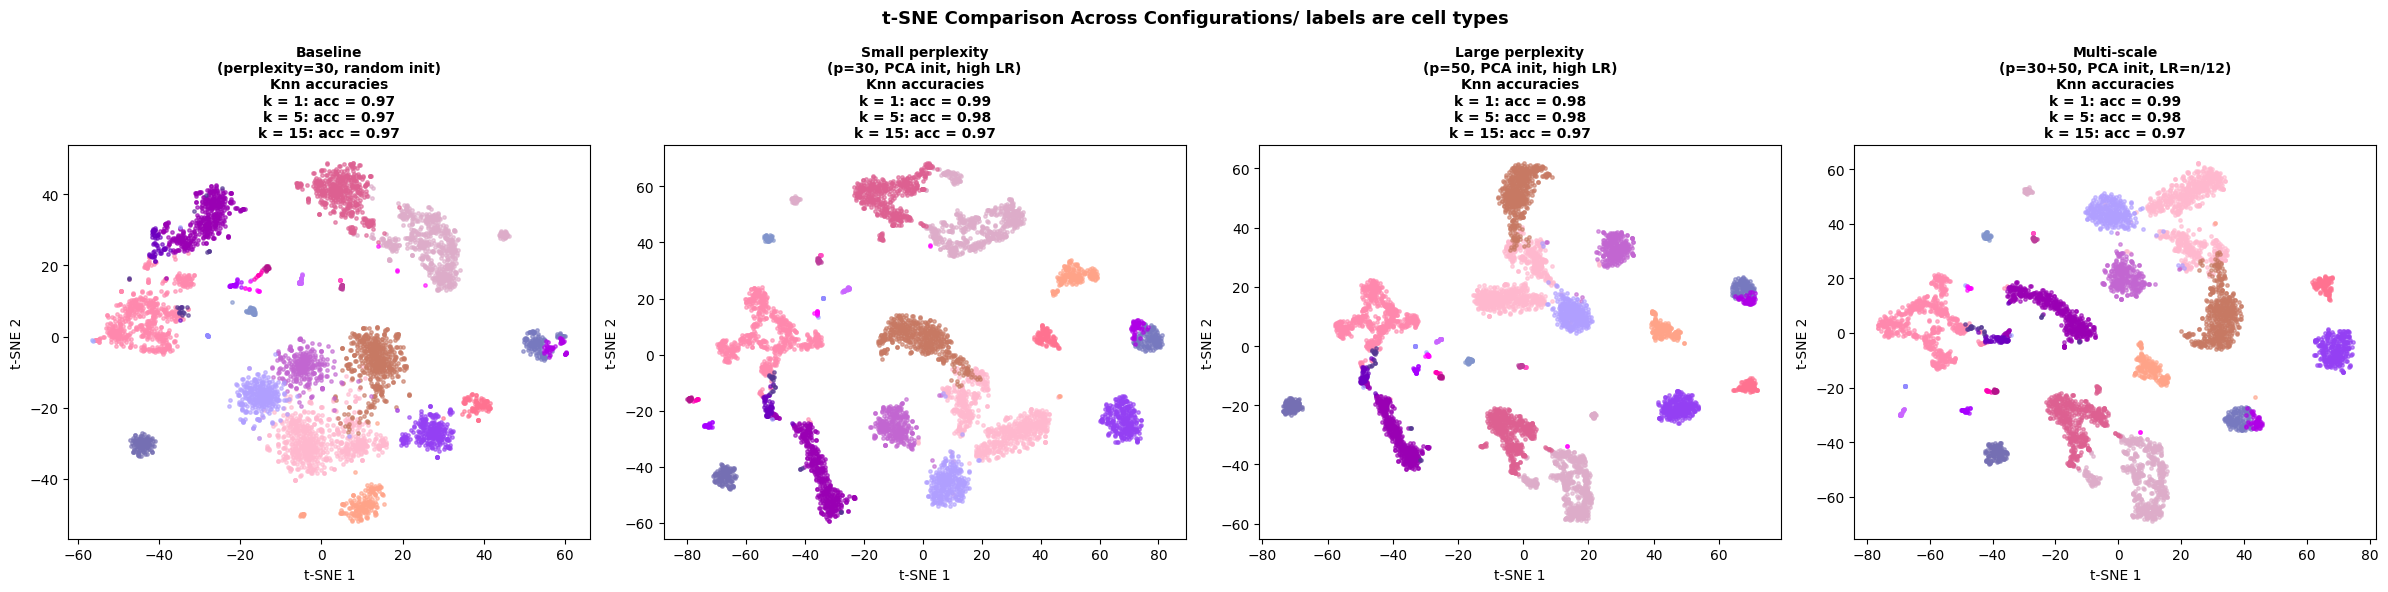

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

results = [
    (tsne_result,               "Baseline\n(perplexity=30, random init)"),
    (tsne_small_result,         "Small perplexity\n(p=30, PCA init, high LR)"),
    (tsne_large_result,         "Large perplexity\n(p=50, PCA init, high LR)"),
    (np.array(tsne_proper_result), "Multi-scale\n(p=30+50, PCA init, LR=n/12)"),
]
knn_results = [evaluate_knn(result, data["cell_types"]) for result, _ in results];
metrics_str = ["\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in res.items()]) for res in knn_results]
for ax, (result, title), metric in zip(axes, results, metrics_str):
    for cid in np.unique(data['cell_types']):
        mask = data['cell_types'] == cid
        ax.scatter(result[mask, 0], result[mask, 1],
                   c=data['clusterColors'][cid], s=6, alpha=0.6)
    ax.set_title(f"{title}\n{metric}", fontsize=10, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    #ax.axis("Off")

plt.suptitle("t-SNE Comparison Across Configurations/ labels are cell types",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[kNN probe]   k=1      acc=0.7720  macro-F1=0.6766
[kNN probe]   k=5      acc=0.7740  macro-F1=0.6671
[kNN probe]   k=15     acc=0.7580  macro-F1=0.5841


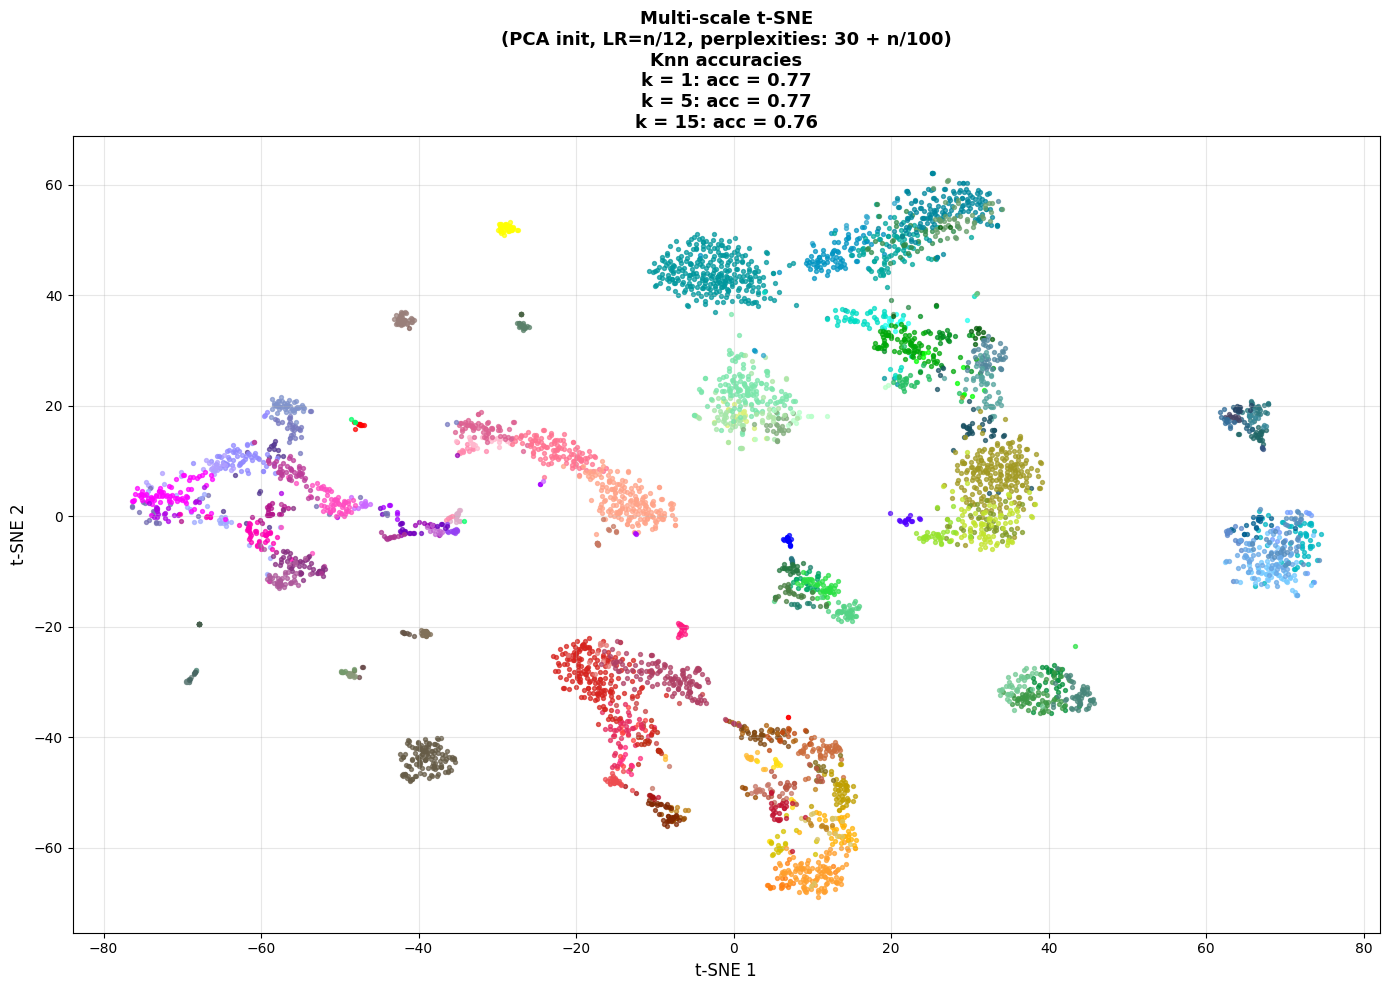

In [ ]:
# ── Final best t-SNE: multi-scale — standalone high-quality plot ──────────
best_result = np.array(tsne_proper_result)
res = evaluate_knn(best_result, clusters)
metric_str = "\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in res.items()])
plt.figure(figsize=(14, 10))
for cid in np.unique(data['clusters']):
    mask = data['clusters'] == cid
    plt.scatter(best_result[mask, 0], best_result[mask, 1],
                c=data['clusterColors'][cid], s=8, alpha=0.7,
                label=data['clusterNames'][cid])
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.title(
    f"Multi-scale t-SNE\n(PCA init, LR=n/12, perplexities: 30 + n/100)\n{metric_str}",
    fontsize=13, fontweight='bold'
)
#plt.axis("off")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


[kNN probe]   k=1      acc=0.9870  macro-F1=0.9435
[kNN probe]   k=5      acc=0.9830  macro-F1=0.9123
[kNN probe]   k=15     acc=0.9750  macro-F1=0.8101


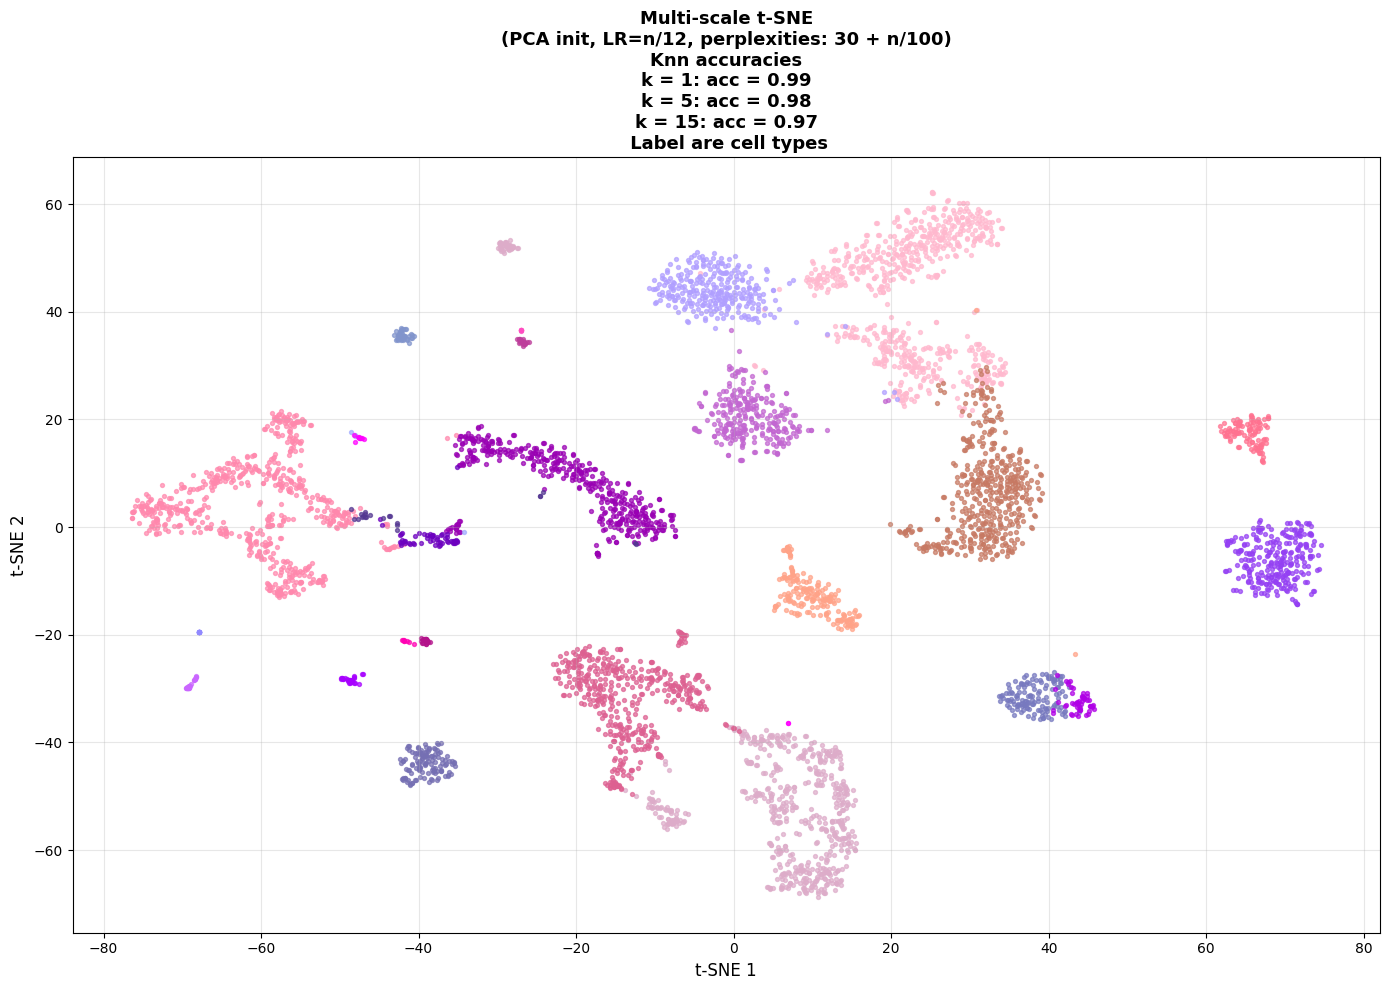

In [ ]:
# ── Final best t-SNE: multi-scale — standalone high-quality plot ──────────
best_result = np.array(tsne_proper_result)
res = evaluate_knn(best_result, data["cell_types"])
metric_str = "\n".join(["Knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in res.items()])
plt.figure(figsize=(14, 10))
for cid in np.unique(data['cell_types']):
    mask = data['cell_types'] == cid
    plt.scatter(best_result[mask, 0], best_result[mask, 1],
                c=data['clusterColors'][cid], s=8, alpha=0.7,
                label=data['clusterNames'][cid])
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.title(
    f"Multi-scale t-SNE\n(PCA init, LR=n/12, perplexities: 30 + n/100)\n{metric_str}\n Label are cell types",
    fontsize=13, fontweight='bold'
)
#plt.axis("off")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


─── Class Divergence Analysis (scaled to [0,10]) ───────────────
[Clustering]  K-Means    ARI=0.3538  NMI=0.7693
  Baseline (p=30, random init)                   ari=0.3538  nmi=0.7693
[Clustering]  K-Means    ARI=0.3845  NMI=0.8025
  Small perplexity (p=30, PCA init)              ari=0.3845  nmi=0.8025
[Clustering]  K-Means    ARI=0.3842  NMI=0.8017
  Large perplexity (p=50, PCA init)              ari=0.3842  nmi=0.8017
[Clustering]  K-Means    ARI=0.3950  NMI=0.8045
  Multi-scale (p=30+50, PCA init)                ari=0.3950  nmi=0.8045


/tmp/ipykernel_712/2077939476.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=45, ha='right')
/tmp/ipykernel_712/2077939476.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=45, ha='right')


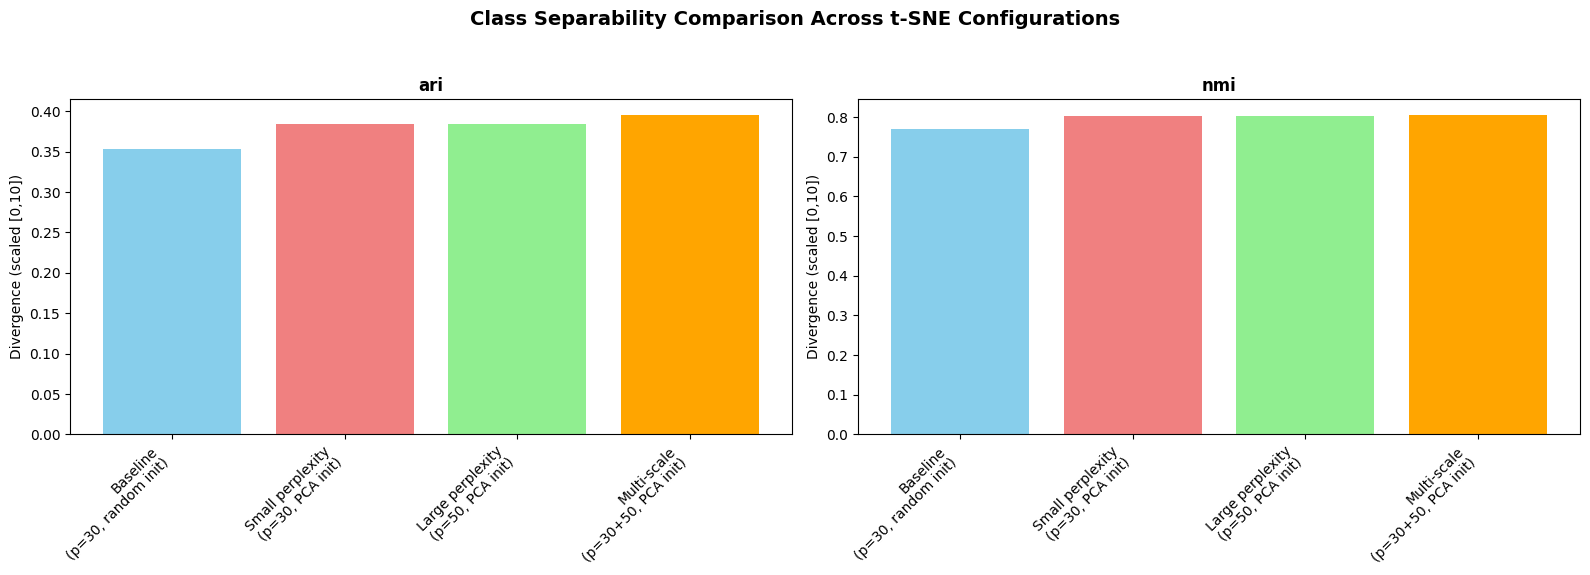

In [ ]:
original_data_methods = {
    "Baseline\n(p=30, random init)": tsne_result,
    "Small perplexity\n(p=30, PCA init)": tsne_small_result,
    "Large perplexity\n(p=50, PCA init)": tsne_large_result,
    "Multi-scale\n(p=30+50, PCA init)": np.array(tsne_proper_result),
}
scaled_data_methods = original_data_methods.copy()

method_names    = list(scaled_data_methods.keys())
ari, nmi = [], []

print("\n─── Class Divergence Analysis (scaled to [0,10]) ───────────────")
for name, mat in scaled_data_methods.items():
    res = evaluate_clustering(mat, clusters)
    ari.append(res["ari"])
    nmi.append(res["nmi"])
    print(f"  {name.replace(chr(10),' '):<45}  "
          f"ari={res["ari"]:.4f}  nmi={res["nmi"]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, vals, title in zip(
    axes,
    [ari, nmi],
    ['ari',
     'nmi']
):
    ax.bar(method_names, vals,
           color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Divergence (scaled [0,10])')
    ax.set_xticklabels(method_names, rotation=45, ha='right')

plt.suptitle('Class Separability Comparison Across t-SNE Configurations',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


[Clustering]  K-Means    ARI=0.5933  NMI=0.8313
  Baseline (p=30, random init)                   ari=0.5933  nmi=0.8313
[Clustering]  K-Means    ARI=0.5754  NMI=0.8397
  Small perplexity (p=30, PCA init)              ari=0.5754  nmi=0.8397
[Clustering]  K-Means    ARI=0.6025  NMI=0.8460
  Large perplexity (p=50, PCA init)              ari=0.6025  nmi=0.8460
[Clustering]  K-Means    ARI=0.5801  NMI=0.8406
  Multi-scale (p=30+50, PCA init)                ari=0.5801  nmi=0.8406


/tmp/ipykernel_712/218914612.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=45, ha='right')
/tmp/ipykernel_712/218914612.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=45, ha='right')


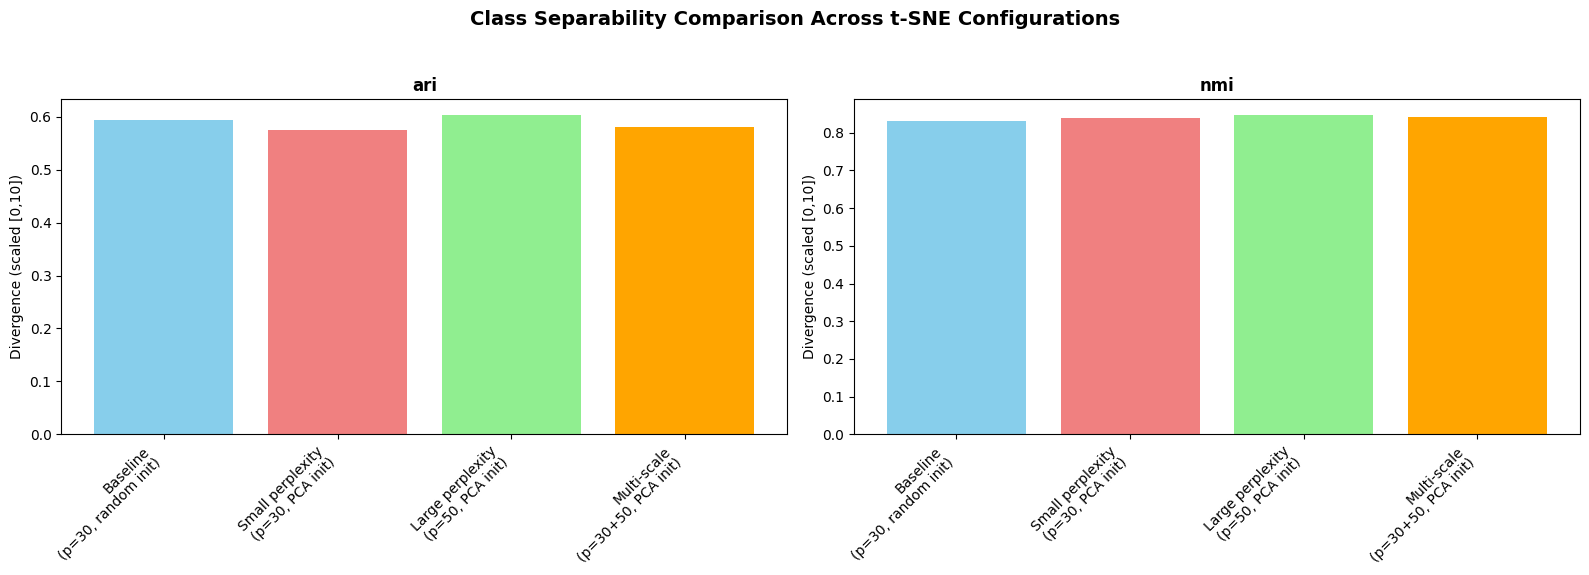

In [ ]:
original_data_methods = {
    "Baseline\n(p=30, random init)": tsne_result,
    "Small perplexity\n(p=30, PCA init)": tsne_small_result,
    "Large perplexity\n(p=50, PCA init)": tsne_large_result,
    "Multi-scale\n(p=30+50, PCA init)": np.array(tsne_proper_result),
}
scaled_data_methods = original_data_methods.copy()

method_names    = list(scaled_data_methods.keys())
ari, nmi = [], []


for name, mat in scaled_data_methods.items():
    res = evaluate_clustering(mat, data["cell_types"])
    ari.append(res["ari"])
    nmi.append(res["nmi"])
    print(f"  {name.replace(chr(10),' '):<45}  "
          f"ari={res["ari"]:.4f}  nmi={res["nmi"]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, vals, title in zip(
    axes,
    [ari, nmi],
    ['ari',
     'nmi']
):
    ax.bar(method_names, vals,
           color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Divergence (scaled [0,10])')
    ax.set_xticklabels(method_names, rotation=45, ha='right')

plt.suptitle('Class Separability Comparison Across t-SNE Configurations',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
!cp -r ./*npy /content/drive/MyDrive/drive/saves_proj/

In [ ]:
from google.colab import drive
drive.mount("/content/MyDrive")

Mounted at /content/MyDrive


In [ ]:
!cp -r  /content/MyDrive/MyDrive/drive/saves_proj/* .

## SSL_embedding + TSNE

In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# import scanpy as sc
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    f1_score,
)
import scipy
import matplotlib.pyplot as plt


CONFIG = {
    "n_top_genes":   2000,
    "batch_size":    256,
    "embedding_dim": 128,
    "projection_dim": 64,
    "hidden_dim":    512,
    "temperature":   0.5,
    "epochs":        100,
    "lr":            1e-3,
    "weight_decay":  1e-5,
    "mask_prob":     0.3,
    "noise_std":     0.1,
    "device":        "cuda" if torch.cuda.is_available() else "cpu",
    "seed":          42,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


def load_tasic_data(path):
    data = pickle.load(open(path, "rb"))
    return data


def lognormalize_counts(tasic_dict):

    counts = tasic_dict['counts']

    # trying to catch all formats in which the counts might be loaded
    if scipy.sparse.issparse(counts):
        counts = counts.toarray()
    elif isinstance(counts, np.matrix):
        counts = np.squeeze(np.asarray(counts))
    else:
        raise TypeError(f"Data format is {type(counts)} but should be np.martix or a sparse matrix.")

    #normalize and logtransform counts
    libsizes = counts.sum(axis=1)
    CPM = counts / libsizes[:, None] * 1e+6

    logCPM = np.log2(CPM + 1)
    tasic_dict['logCPM'] = logCPM

    return tasic_dict


def preprocess(data):
    data = lognormalize_counts(data)
    return data


class SCAugmentations:
    """
    Two cheap augmentations that work well on scRNA-seq:
        - Random gene masking (mimics technical dropout)
        - Gaussian noise (mimics measurement noise)
    """
    def __init__(self, mask_prob=0.3, noise_std=0.1):
        self.mask_prob = mask_prob
        self.noise_std = noise_std

    def __call__(self, x):
        mask = (torch.rand_like(x) > self.mask_prob).float()
        x_aug = x * mask
        x_aug = x_aug + torch.randn_like(x_aug) * self.noise_std
        return x_aug


class ContrastiveSCDataset(Dataset):
    """Returns two augmented views of the same cell."""
    def __init__(self, X, augment):
        self.X = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.augment = augment

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        return self.augment(x), self.augment(x)


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, embedding_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        return self.net(x)


class ProjectionHead(nn.Module):
    def __init__(self, embedding_dim, projection_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, projection_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class SimCLRModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, embedding_dim, projection_dim):
        super().__init__()
        self.encoder   = Encoder(input_dim, hidden_dim, embedding_dim)
        self.projector = ProjectionHead(embedding_dim, projection_dim)

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


def nt_xent_loss(z1, z2, temperature=0.5):
    """
    z1, z2: (B, D) L2-normalized projections of two views.
    Positives: (i, i) pairs across z1/z2. Negatives: all other cells.
    """
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)                       # (2B, D)
    sim = torch.mm(z, z.t()) / temperature               # (2B, 2B)

    # Remove self-similarity
    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, float("-inf"))

    # Positive index for sample i is i+B (and vice versa)
    targets = (torch.arange(2 * B, device=z.device) + B) % (2 * B)
    return F.cross_entropy(sim, targets)


def train_ssl(model, loader, cfg, obj=nt_xent_loss):
    opt = torch.optim.Adam(model.parameters(),
                           lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])

    model.train()
    history = []
    for epoch in range(cfg["epochs"]):
        running = 0.0
        for x1, x2 in loader:
            x1 = x1.to(cfg["device"], non_blocking=True)
            x2 = x2.to(cfg["device"], non_blocking=True)

            _, z1 = model(x1)
            _, z2 = model(x2)
            loss = obj(z1, z2, cfg["temperature"])

            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item() * x1.size(0)

        sched.step()
        avg = running / len(loader.dataset)
        history.append(avg)
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{cfg['epochs']} | loss={avg:.4f}")
    return history


@torch.no_grad()
def extract_embeddings(model, X, device, batch_size=512, backbone=True):
    model.eval()
    X_t = torch.from_numpy(np.ascontiguousarray(X)).float()
    out = []
    for i in range(0, X_t.size(0), batch_size):
        batch = X_t[i:i + batch_size].to(device)
        h, z = model(batch)
        # Corrected: Directly append the numpy array, not the result of list.append()
        if backbone:
            out.append(h.cpu().numpy())
        else:
            out.append(z.cpu().numpy())
    return np.concatenate(out, axis=0)


def evaluate_clustering(embeddings, labels, n_clusters=None):
    """Unsupervised: fit K-Means on embeddings, score against true labels."""
    if n_clusters is None:
        n_clusters = len(np.unique(labels))
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit(embeddings)
    ari = adjusted_rand_score(labels, km.labels_)
    nmi = normalized_mutual_info_score(labels, km.labels_)
    print(f"[Clustering]  K-Means    ARI={ari:.4f}  NMI={nmi:.4f}")
    return {"ari": ari, "nmi": nmi}


def evaluate_knn(embeddings, labels, k_values=(1, 5, 15), test_size=0.2, metric = "cosine", seed=0):
    """
    Standard SSL linear/kNN probe:
        Split embeddings into train/test, fit kNN on train, predict on test.
    Reports accuracy + macro-F1 (macro-F1 matters because TASIC cell types are
    very imbalanced — rare types would otherwise be hidden by accuracy).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        embeddings, labels,
        test_size=test_size,
        # stratify=labels,
        random_state=seed,
    )
    results = {}
    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric = metric)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te) # Corrected from y_te to X_te
        acc = accuracy_score(y_te, y_pred)
        f1m = f1_score(y_te, y_pred, average="macro")
        results[k] = {"acc": acc, "macro_f1": f1m}
        print(f"[kNN probe]   k={k:<3d}    acc={acc:.4f}  macro-F1={f1m:.4f}")
    return results

def visualize_history(history, prefix ="tasic_ssl_clr" ):
    plt.plot(history)
    plt.title("Training history")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.savefig(f"{prefix}_history.png", dpi=600)
    plt.close()

def visualize(embeddings, labels, prefix="tasic_ssl", load = False):
    """Project embeddings to 2-D with both UMAP and t-SNE, save side-by-side."""
    # t-SNE
    print("Running t-SNE…")
    if not load:
      tsne = TSNE(n_components=2, perplexity=30, init="pca",
                  learning_rate="auto", random_state=0)
      emb_tsne = tsne.fit_transform(embeddings)
      np.save(f"{prefix}_tsne.npy", emb_tsne)

      # UMAP

    emb_umap = None

    try:
      emb_tsne = np.load(f"tasic_ssl_tsne.npy")
    except Exception:
      print("error")
      return

    knn_tsne = evaluate_knn(embeddings, labels)
    #knn_umap = evaluate_knn(emb_umap, labels)
    tsne_metrics_str = "\n".join(["t-SNE knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_tsne.items()])
    #umap_metrics_str = "\n".join(["UMAP knn accuracies"]+[f"k = {k}: acc = {v['acc']:.2f}" for k,v in knn_umap.items()])
    n_panels = 2 if emb_umap is not None else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]

    axes[0].scatter(emb_tsne[:, 0], emb_tsne[:, 1],
                    c=labels, s=3, cmap="tab20")
    axes[0].set_title("t-SNE of SSL embeddings")
    axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")
    #add the metrics str at the right
    axes[0].text(0.95, 0.95, tsne_metrics_str,
                 transform=axes[0].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right')
    #axes[0].axis("off")
    #axes[1].set_visible(False)
    #fig.suptitle("TASIC — SimCLR self-supervised embeddings")
    plt.tight_layout()
    out_path = f"{prefix}_2d.png"
    plt.savefig(out_path, dpi=600)
    plt.close()
    print(f"Saved 2-D projections to {out_path}")

In [ ]:
import os

def main(data_path="tasic_subset_1kselectedB.pickle", label_key="clusters", label_key_2 = "cell_types", load_model=False):
    cfg = CONFIG

    print("Loading TASIC…")
    data,_,_ = get_data_and_labels(data_path)
    labels2 = data[label_key_2]
    data = lognormalize_counts(data)

    X = data['logCPM'].toarray() if hasattr(data['logCPM'], "toarray") else data['logCPM']

    loader = DataLoader(
        ContrastiveSCDataset(X, SCAugmentations(cfg["mask_prob"], cfg["noise_std"])),
        batch_size=cfg["batch_size"], shuffle=True,
        num_workers=4, drop_last=True, pin_memory=True,
    )

    model = SimCLRModel(
        input_dim=X.shape[1],
        hidden_dim=cfg["hidden_dim"],
        embedding_dim=cfg["embedding_dim"],
        projection_dim=cfg["projection_dim"],
    ).to(cfg["device"])

    model_path = "tasic_ssl_model.pt"

    if load_model and os.path.exists(model_path):
        print(f"Loading pre-trained model from {model_path}…")
        model.load_state_dict(torch.load(model_path, map_location=torch.device(cfg["device"])))
        model.eval() # Set model to evaluation mode
        history = np.load("tasic_ssl_loss_history.npy")
    else:
        print("Pre-training with contrastive SSL…")
        history = train_ssl(model, loader, cfg)
        torch.save(model.state_dict(), model_path)
        print(f"Saved model weights to {model_path}")
        print("#saving the loss history")
        np.save("tasic_ssl_loss_history.npy", history)
        visualize_history(history)

    print("Extracting embeddings…")
    embeddings = extract_embeddings(model, X, cfg["device"])
    np.save("tasic_ssl_embeddings.npy", embeddings)

    labels = None # Initialize labels for consistent return
    if label_key in data:
        labels = data[label_key]
        evaluate_clustering(embeddings, labels)
        evaluate_knn(embeddings, labels, metric="cosine") # Added metric for consistency
        visualize(embeddings, labels, load=True)
    else:
        print(f"No '{label_key}' column in data; skipping evaluation.")
    if label_key_2 in data:
        print("ohhh")
        evaluate_clustering(embeddings, labels2)
        evaluate_knn(embeddings, labels2, metric="cosine") # Added metric for consistency
        visualize(embeddings, labels2, load=True, prefix = "tasic_ssl_cell_types")

    return model, embeddings, labels, labels2 # Return labels as well

# Call the main function and store its results in global variables for subsequent cells
model_trained, embeddings, labels, labels2 = main(load_model = False)

Loading TASIC…
Pre-training with contrastive SSL…


/tmp/ipykernel_712/976225543.py:44: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  data = pickle.load(open(path, "rb"))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be awa

Epoch   1/100 | loss=5.0295
Epoch   5/100 | loss=4.4972
Epoch  10/100 | loss=4.4150
Epoch  15/100 | loss=4.3811
Epoch  20/100 | loss=4.3644
Epoch  25/100 | loss=4.3500
Epoch  30/100 | loss=4.3447
Epoch  35/100 | loss=4.3322
Epoch  40/100 | loss=4.3275
Epoch  45/100 | loss=4.3250
Epoch  50/100 | loss=4.3197
Epoch  55/100 | loss=4.3185
Epoch  60/100 | loss=4.3142
Epoch  65/100 | loss=4.3136
Epoch  70/100 | loss=4.3077
Epoch  75/100 | loss=4.3065
Epoch  80/100 | loss=4.3044
Epoch  85/100 | loss=4.3054
Epoch  90/100 | loss=4.3025
Epoch  95/100 | loss=4.3070
Epoch 100/100 | loss=4.3042
Saved model weights to tasic_ssl_model.pt
#saving the loss history
Extracting embeddings…
[Clustering]  K-Means    ARI=0.4038  NMI=0.7933
[kNN probe]   k=1      acc=0.7470  macro-F1=0.6070
[kNN probe]   k=5      acc=0.7870  macro-F1=0.6431
[kNN probe]   k=15     acc=0.7670  macro-F1=0.5815
Running t-SNE…
[kNN probe]   k=1      acc=0.7470  macro-F1=0.6070
[kNN probe]   k=5      acc=0.7870  macro-F1=0.6431
[kNN

(np.float64(-0.5), np.float64(3839.5), np.float64(2879.5), np.float64(-0.5))

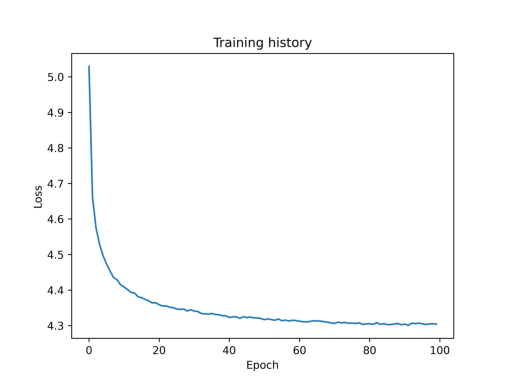

In [ ]:
plt.imshow(plt.imread("tasic_ssl_clr_history.png"))
plt.axis("off")

(np.float64(-0.5), np.float64(4199.5), np.float64(3599.5), np.float64(-0.5))

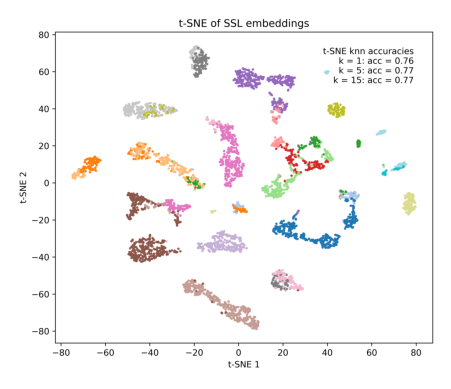

In [ ]:
plt.imshow(plt.imread("tasic_ssl_2d.png"))
plt.axis("off")

(np.float64(-0.5), np.float64(4199.5), np.float64(3599.5), np.float64(-0.5))

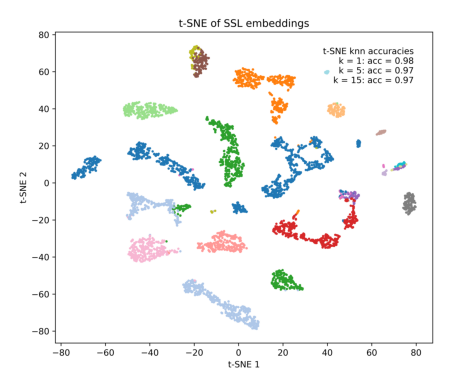

In [ ]:
plt.imshow(plt.imread("tasic_ssl_cell_types_2d.png"))
plt.axis("off")

In [ ]:
evaluate_clustering(embeddings, labels)

[Clustering]  K-Means    ARI=0.4039  NMI=0.7944


{'ari': 0.4039333914471724, 'nmi': np.float64(0.7943871968490006)}

In [ ]:
evaluate_clustering(embeddings, labels2)

[Clustering]  K-Means    ARI=0.5951  NMI=0.8460


{'ari': 0.5950515582143252, 'nmi': np.float64(0.8459646197397899)}

## TSIMCNE model

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tasic_ssl import (
    load_tasic_data,
    preprocess,
    SCAugmentations,
    ContrastiveSCDataset,
    evaluate_clustering,
    evaluate_knn,
)


CONFIG = {
    # data
    "n_top_genes":   2000,
    "default_sim_metric": "euclidian_sim",
    "batch_size":    512,
    "feature_dim":   256,
    "head_hidden":   1024,
    "stage1_out":    128,
    "final_out":     2,
    "mask_prob":     0.3,
    "noise_std":     0.1,
    "stage1_epochs": 200,
    "stage2_epochs": 30,
    "stage3_epochs": 100,
    "stage1_lr":     1e-3,
    "stage2_lr":     1e-3,
    "stage3_lr":     1e-4,
    "weight_decay":  1e-5,
    "device":        "cuda" if torch.cuda.is_available() else "cpu",
    "seed":          42,
    "temperature":   0.5,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


class MLPBackbone(nn.Module):
    def __init__(self, input_dim, feature_dim=256, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
        )

    def forward(self, x):
        return self.net(x)


class ProjectionHead(nn.Module):

    def __init__(self, feature_dim=256, hidden_dim=1024, out_dim=128):
        super().__init__()
        self.fc_hidden = nn.Linear(feature_dim, hidden_dim)
        self.fc_out    = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = F.relu(self.fc_hidden(x))
        return self.fc_out(x)

    def replace_output_layer(self, new_out_dim, device=None):
        """Swap the final linear layer (carry over the hidden layer's weights)."""
        in_dim = self.fc_out.in_features
        self.fc_out = nn.Linear(in_dim, new_out_dim)
        if device is not None:
            self.fc_out.to(device)


class TSimCNE(nn.Module):
    def __init__(self, input_dim, feature_dim=256, head_hidden=1024, out_dim=128):
        super().__init__()
        self.backbone = MLPBackbone(input_dim, feature_dim=feature_dim)
        self.head     = ProjectionHead(feature_dim, head_hidden, out_dim)

    def forward(self, x):
        h = self.backbone(x)
        z = self.head(h)
        return h, z

euclidian_dist = lambda x, y: torch.cdist(x, y, p=2).pow(2)
def cosine_dist(z1, z2):
    # 1. Normalize embeddings to unit hypersphere
    z1 = F.normalize(z1, p=2, dim=1)
    z2 = F.normalize(z2, p=2, dim=1)
    # 2. Compute cosine similarity (ranges from -1 to 1)
    return 1 - torch.mm(z1, z2.t())
def info_nce_cauchy(z1, z2, sim_metric = "euclidian_sim", temperature=1.0):
    if sim_metric == "euclidian_sim":
        dist_metric = euclidian_dist
    elif sim_metric == "cosine_sim":
        dist_metric = cosine_dist
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    dist = dist_metric(z, z)
    log_sim = -torch.log1p(dist) / temperature # Apply temperature here
    diag = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    log_sim = log_sim.masked_fill(diag, float("-inf"))
    targets = (torch.arange(2 * B, device=z.device) + B) % (2 * B)
    return F.cross_entropy(log_sim, targets)


def train_stage(model, loader, *, epochs, lr, weight_decay, params, device, tag, sim_metric="euclidian_sim", temperature=1.0):
    opt   = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x1, x2 in loader:
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)

            _, z1 = model(x1)
            _, z2 = model(x2)
            loss = info_nce_cauchy(z1, z2, sim_metric = sim_metric, temperature=temperature)

            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item() * x1.size(0)

        sched.step()
        avg = running / len(loader.dataset)
        history.append(avg)
        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f"  [{tag}] epoch {epoch+1:3d}/{epochs}  loss={avg:.4f}")
    return history


def train_tsimcne(model, loader, cfg, sim_metric = "euclidian_sim"):
    device = cfg["device"]
    history = {}

    print("\n=== Stage 1: pre-training (full net, "
          f"{cfg['stage1_out']}-D head output) ===")
    history["stage1"] = train_stage(
        model, loader,
        epochs=cfg["stage1_epochs"], lr=cfg["stage1_lr"],
        weight_decay=cfg["weight_decay"],
        params=model.parameters(),
        device=device, tag="stage 1",sim_metric = sim_metric, temperature=cfg["temperature"]
    )

    print(f"\n--- Replacing projection head's last layer "
          f"({cfg['stage1_out']} -> {cfg['final_out']}) ---")
    model.head.replace_output_layer(cfg["final_out"], device=device)

    print("\n=== Stage 2: training projection head only (backbone frozen, 2-D) ===")
    for p in model.backbone.parameters():
        p.requires_grad = False
    history["stage2"] = train_stage(
        model, loader,
        epochs=cfg["stage2_epochs"], lr=cfg["stage2_lr"],
        weight_decay=cfg["weight_decay"],
        params=filter(lambda p: p.requires_grad, model.parameters()),
        device=device, tag="stage 2",sim_metric = sim_metric, temperature=cfg["temperature"]
    )

    print("\n=== Stage 3: fine-tuning whole model (backbone + 2-D head) ===")
    for p in model.backbone.parameters():
        p.requires_grad = True
    history["stage3"] = train_stage(
        model, loader,
        epochs=cfg["stage3_epochs"], lr=cfg["stage3_lr"],
        weight_decay=cfg["weight_decay"],
        params=model.parameters(),
        device=device, tag="stage 3",sim_metric = sim_metric, temperature=cfg["temperature"]
    )
    return history


def plot_loss_history(history, out_path="tasic_tsimcne_loss.png"):
    s1, s2, s3 = history["stage1"], history["stage2"], history["stage3"]
    all_loss = s1 + s2 + s3
    plt.figure(figsize=(9, 4))
    plt.plot(all_loss, lw=1.2)
    plt.axvline(len(s1) - 0.5, color="grey", ls="--", lw=0.8)
    plt.axvline(len(s1) + len(s2) - 0.5, color="grey", ls="--", lw=0.8)
    plt.text(len(s1) / 2, max(all_loss), "stage 1", ha="center", va="top")
    plt.text(len(s1) + len(s2) / 2, max(all_loss), "stage 2", ha="center", va="top")
    plt.text(len(s1) + len(s2) + len(s3) / 2, max(all_loss),
             "stage 3", ha="center", va="top")
    plt.xlabel("epoch (cumulative)"); plt.ylabel("Cauchy InfoNCE loss")
    plt.title("t-SimCNE training loss across stages")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved loss curve to {out_path}")


@torch.no_grad()
def extract_embeddings(model, X, device, batch_size=512):
    """
    Returns both the 2-D head output (the visualization) and the backbone
    features (for comparing kNN accuracy at different depths of the network).
    """
    model.eval()
    X_t = torch.from_numpy(np.ascontiguousarray(X)).float()
    feats, embs = [], []
    for i in range(0, X_t.size(0), batch_size):
        batch = X_t[i:i + batch_size].to(device)
        h, z = model(batch)
        feats.append(h.cpu().numpy())
        embs.append(z.cpu().numpy())
    return np.concatenate(feats, 0), np.concatenate(embs, 0)


def visualize_2d(emb_2d, labels, out_path="tasic_tsimcne_2d.png"):
    plt.figure(figsize=(8, 7))
    sc = plt.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=labels, s=4, cmap="tab20", alpha=0.8)
    plt.title("TASIC — t-SimCNE 2-D embedding (direct, no t-SNE / UMAP)")
    plt.xlabel("dim 1"); plt.ylabel("dim 2")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved 2-D embedding plot to {out_path}")

In [ ]:


def main(data_path, label_key="clusters", sim_metric = CONFIG["default_sim_metric"]):
    cfg = CONFIG

    print("Loading TASIC...")
    data = load_tasic_data(data_path)
    data = preprocess(data)
    X = data['logCPM'].toarray() if hasattr(data['logCPM'], "toarray") else data['logCPM']

    loader = DataLoader(
        ContrastiveSCDataset(X, SCAugmentations(cfg["mask_prob"], cfg["noise_std"])),
        batch_size=cfg["batch_size"], shuffle=True,
        num_workers=4, drop_last=True, pin_memory=True,
    )

    model = TSimCNE(
        input_dim=X.shape[1],
        feature_dim=cfg["feature_dim"],
        head_hidden=cfg["head_hidden"],
        out_dim=cfg["stage1_out"],
    ).to(cfg["device"])

    model_path = f"tasic_tsimcne_model{'' if sim_metric== 'euclidian_sim' else '_cosine'}.pt"

    if os.path.exists(model_path):
        print(f"Loading pre-trained model from {model_path}…")
        # Adjust the projection head's output layer to the final_out dimension
        # before loading state_dict, as it was changed during training.
        model.head.replace_output_layer(cfg["final_out"], device=cfg["device"])
        model.load_state_dict(torch.load(model_path, map_location=torch.device(cfg["device"])))
        model.eval() # Set model to evaluation mode
        # Load existing history or create a dummy one if needed for plotting
        # For now, we'll assume plotting loss history is only relevant for training
        history = {"stage1": [], "stage2": [], "stage3": []} # Dummy history for consistency
    else:
        print("Pre-training TSimCNE…")
        history = train_tsimcne(model, loader, cfg, sim_metric = sim_metric)
        print("Done.")
        plot_loss_history(history, out_path=f"tasic_tsimcne_loss{'' if sim_metric== 'euclidian_sim' else '_cosine'}.png")
        torch.save(model.state_dict(), model_path)
        print(f"Saved model weights to {model_path}")

    print("\nExtracting embeddings...")
    feats, emb_2d = extract_embeddings(model, X, cfg["device"])
    np.save(f"tasic_tsimcne_2d{'' if sim_metric== 'euclidian_sim' else '_cosine'}.npy",      emb_2d)
    np.save(f"tasic_tsimcne_features{'' if sim_metric== 'euclidian_sim' else '_cosine'}.npy", feats)

    if label_key in data:
        labels = data[label_key]
        print(f"\n=== Evaluation on the 2-D t-SimCNE embedding "
              f"({len(np.unique(labels))} classes) ===")
        evaluate_clustering(emb_2d, labels)
        evaluate_knn(emb_2d, labels)

        print(f"\n=== Evaluation on the {cfg['feature_dim']}-D backbone "
              f"features (analog of SimCLR's 'h') ===")
        evaluate_clustering(feats, labels)
        evaluate_knn(feats, labels)
        visualize_2d(emb_2d, labels, out_path=f"tasic_tsimcne_2d{'' if sim_metric== 'euclidian_sim' else '_cosine'}.png")
    else:
        print(f"No '{label_key}' column in data; skipping evaluation.")

    return model, emb_2d, feats

### using euclidian distance

In [ ]:
import sys
path = "tasic_subset_1kselectedB.pickle"#"tasic.h5ad"
key  ="clusters"
_=main(path, key)

Loading TASIC...
Loading pre-trained model from tasic_tsimcne_model.pt…

Extracting embeddings...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



=== Evaluation on the 2-D t-SimCNE embedding (133 classes) ===
[Clustering]  K-Means    ARI=0.4112  NMI=0.7974
[kNN probe]   k=1      acc=0.7150  macro-F1=0.5771
[kNN probe]   k=5      acc=0.7380  macro-F1=0.5669
[kNN probe]   k=15     acc=0.7490  macro-F1=0.5547

=== Evaluation on the 256-D backbone features (analog of SimCLR's 'h') ===
[Clustering]  K-Means    ARI=0.4368  NMI=0.8108
[kNN probe]   k=1      acc=0.7870  macro-F1=0.7067
[kNN probe]   k=5      acc=0.7880  macro-F1=0.6953
[kNN probe]   k=15     acc=0.7930  macro-F1=0.6308
Saved 2-D embedding plot to tasic_tsimcne_2d.png


In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_2d.png"))

### using cosine similarity

In [ ]:
import sys
path = "tasic_subset_1kselectedB.pickle"#"tasic.h5ad"
key  ="clusters"
_=main(path, key, sim_metric = "cosine_sim")

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_2d_cosine.png"))

In [ ]:
!rm -rf /content/MyDrive/MyDrive/

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/MyDrive


# evaluation and plotting using cell types instead of subcell types (TSIMCNE)

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
##load previous work
!cp -r /content/drive/MyDrive/drive/saves_proj/* .

In [6]:
from tsimcne2 import *
import matplotlib.patheffects as effects
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    f1_score,
)

In [7]:
path_effects = [effects.withStroke(linewidth=1.5, foreground='black')]
def visualize_2d_(emb_2d, emb, labels, label_to_legend_dict, colors, colors2,out_path="tasic_tsimcne_2d.png",anotate=True):
    fig, ax = plt.subplots(figsize=(8,6))
    knn_results = evaluate_knn(emb, labels, k_values=(1, 5, 15), test_size=0.2, seed=0)
    metrics_str = "\n".join([f"k={k}, acc = {v['acc']:.2f}" for k,v in knn_results.items()])
    for label in set(labels):
      legend_name = label_to_legend_dict[label]
      #print("legend_name", legend_name)
      idx = [i for i in range(len(labels)) if labels[i] == label]
      centroid = np.median(emb_2d[idx,:], axis=0)
      #print("centroid", centroid)
      ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], c = colors[label], label=legend_name, s=4, alpha=0.8)
      if anotate:
        ax.annotate(
          legend_name,
          xy=(centroid[0], centroid[1]),
          xytext=(0, 0),             # 5 points right and up from the dot
          textcoords="offset points",
          color=colors[label],
          fontweight='bold',
          path_effects= path_effects
      )
    ax.set_title(f"t-SimCNE 2-D embedding\n{metrics_str}")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    plt.tight_layout()
    plt.legend()
    #plt.axis("off")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"Saved 2-D embedding plot to {out_path}")

def visualize_2d__(emb_2d, labels, emb=False,out_path="tasic_tsimcne_2d.png"):
    knn_results = evaluate_knn(emb, labels, k_values=(1, 5, 15), test_size=0.2, seed=0)
    metrics_str = "\n".join([f"k={k}, acc = {v['acc']:.2f}" for k,v in knn_results.items()])
    plt.figure(figsize=(8, 7))
    sc = plt.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=labels, s=4, cmap="tab20", alpha=0.8)
    plt.title(f"t-SimCNE 2-D embedding\n{metrics_str}")
    plt.xlabel("dim 1"); plt.ylabel("dim 2")
    plt.tight_layout()
    #plt.axis("off")
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved 2-D embedding plot to {out_path}")


## training the model

In [8]:
data_path = "/content/tasic_subset_1kselectedB.pickle"

In [ ]:
main(data_path)

Loading TASIC…
Loading pre-trained model from tasic_ssl_model.pt…
Extracting embeddings…


/tmp/ipykernel_1963/75917459.py:44: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  data = pickle.load(open(path, "rb"))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Clustering]  K-Means    ARI=0.4039  NMI=0.7944
[kNN probe]   k=1      acc=0.7640  macro-F1=0.6525
[kNN probe]   k=5      acc=0.7650  macro-F1=0.6249
[kNN probe]   k=15     acc=0.7740  macro-F1=0.5704
Running t-SNE…
[kNN probe]   k=1      acc=0.7640  macro-F1=0.6525
[kNN probe]   k=5      acc=0.7650  macro-F1=0.6249
[kNN probe]   k=15     acc=0.7740  macro-F1=0.5704
[kNN probe]   k=1      acc=0.4900  macro-F1=0.3593
[kNN probe]   k=5      acc=0.5610  macro-F1=0.3822
[kNN probe]   k=15     acc=0.5880  macro-F1=0.3898
Saved 2-D projections to tasic_ssl_2d.png


(SimCLRModel(
   (encoder): Encoder(
     (net): Sequential(
       (0): Linear(in_features=1000, out_features=512, bias=True)
       (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (2): ReLU()
       (3): Dropout(p=0.1, inplace=False)
       (4): Linear(in_features=512, out_features=512, bias=True)
       (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (6): ReLU()
       (7): Dropout(p=0.1, inplace=False)
       (8): Linear(in_features=512, out_features=128, bias=True)
     )
   )
   (projector): ProjectionHead(
     (net): Sequential(
       (0): Linear(in_features=128, out_features=128, bias=True)
       (1): ReLU()
       (2): Linear(in_features=128, out_features=64, bias=True)
     )
   )
 ),
 array([[ 5.6762486 ,  1.3703451 , -1.6287637 , ...,  0.55127704,
          0.8057132 , -0.63097966],
        [-0.86130196, -1.5886996 , -1.2322896 , ...,  0.45358866,
          0.8320428 ,  1.1312149 ],

(np.float64(-0.5), np.float64(1349.5), np.float64(599.5), np.float64(-0.5))

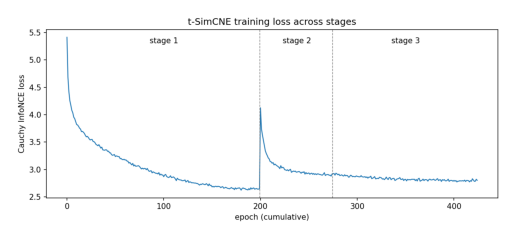

In [42]:
plt.imshow(plt.imread("tasic_tsimcne_loss.png"))
plt.axis("off")

##visualisation of the embeddings(subcell types for colouring)

In [9]:
emb2d = np.load("/content/tasic_tsimcne_2d.npy")
emb_features = np.load("/content/tasic_tsimcne_features.npy")
data = load_tasic_data(data_path)
visualize_2d__(emb2d, data["clusters"], emb_features)

[kNN probe]   k=1      acc=0.7690  macro-F1=0.6726
[kNN probe]   k=5      acc=0.7980  macro-F1=0.6709
[kNN probe]   k=15     acc=0.7840  macro-F1=0.6052
Saved 2-D embedding plot to tasic_tsimcne_2d.png


(np.float64(-0.5), np.float64(1199.5), np.float64(1049.5), np.float64(-0.5))

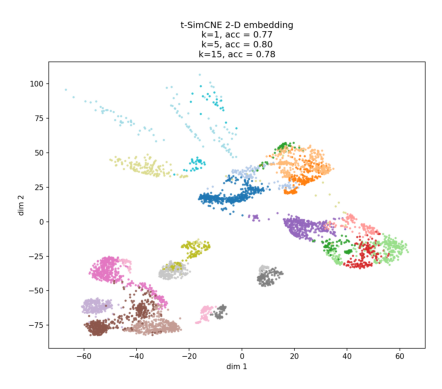

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_2d.png"))
plt.axis("off")

##loading data and preprocessing to assign the correct cell_types

In [10]:
def get_data_and_labels(data_path=data_path):

  data = load_tasic_data(data_path)
  cell_df=pd.read_csv("cell_types.csv")
  subcell_to_cell_type = dict()

  for row in cell_df.iterrows():
    sub_cell_type= row[1]["subtype"]
    cell_type = row[1]["cell_types"]
    if sub_cell_type not in subcell_to_cell_type:
      subcell_to_cell_type[sub_cell_type] = cell_type
  uniques_cell_types_df = cell_df["cell_types"].value_counts()

  cell_labels = list(range(len(uniques_cell_types_df)))
  cell_type_to_cell_label = dict()
  for cell_type in uniques_cell_types_df.index:
    cell_type_to_cell_label[cell_type] = cell_labels[uniques_cell_types_df.index.get_loc(cell_type)]

  data["cell_types"] = [cell_type_to_cell_label[subcell_to_cell_type[data["clusterNames"][el].strip()]] for el in data["clusters"]]

  data["cell_types"]
  cell_type_to_cell_label_ = {v:k for k,v in cell_type_to_cell_label.items()}
  return data, cell_type_to_cell_label, cell_type_to_cell_label_

data , cell_type_to_cell_label, cell_type_to_cell_label_ = get_data_and_labels()

## loading the saved embbedings

In [ ]:
emb2d = np.load("/content/tasic_tsimcne_2d.npy")

In [ ]:
def save_confusion_matrix_from_knn(embeddings, labels, k_values=(1, 5, 15), test_size=0.2, seed=0):

  X_tr, X_te, y_tr, y_te = train_test_split(
        embeddings, labels,
        test_size=test_size,
        # stratify=labels,
        random_state=seed,
    )
  for k in k_values:
    fig, axs = plt.subplots(figsize=(10,10))
    clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    cm = confusion_matrix(y_te, y_pred)
    im = axs.imshow(cm, cmap="Blues") # Store the image object
    fig.colorbar(im, ax=axs) # Add color bar

    # Display actual values in the cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axs.text(j, i, cm[i, j], ha="center", va="center", color="black") # Add text labels

    axs.set_title(f"k={k}, acc={acc:.3f}, f1={f1m:.3f}")
    axs.set_xlabel("Predicted label")
    axs.set_ylabel("True label")
    fig.suptitle("Confusion Matrices for Knn")
    plt.tight_layout()
    plt.savefig(f"tasic_tsimcne_confusion_matrix_{k}.png", dpi=200)
    plt.close()

## knn accuracy evaluation of the model on subcell types

In [ ]:
evaluate_clustering(emb_features, data["clusters"])

[Clustering]  K-Means    ARI=0.4695  NMI=0.8123


{'ari': 0.4694765123556858, 'nmi': np.float64(0.8122715165590927)}

In [ ]:
evaluate_knn(emb_features, data["clusters"])

[kNN probe]   k=1      acc=0.7690  macro-F1=0.6726
[kNN probe]   k=5      acc=0.7980  macro-F1=0.6709
[kNN probe]   k=15     acc=0.7840  macro-F1=0.6052


{1: {'acc': 0.769, 'macro_f1': 0.672609973260905},
 5: {'acc': 0.798, 'macro_f1': 0.6708972685934598},
 15: {'acc': 0.784, 'macro_f1': 0.60520969861522}}

## knn accuracy evaluation of the model on cell types

In [ ]:
evaluate_knn(emb_features, data["cell_types"], k_values=(1, 5, 15), test_size=0.2, seed=0)

[kNN probe]   k=1      acc=0.9820  macro-F1=0.9042
[kNN probe]   k=5      acc=0.9810  macro-F1=0.8942
[kNN probe]   k=15     acc=0.9730  macro-F1=0.7736


{1: {'acc': 0.982, 'macro_f1': 0.9041907010655061},
 5: {'acc': 0.981, 'macro_f1': 0.8941565183620597},
 15: {'acc': 0.973, 'macro_f1': 0.7736491677171393}}

In [ ]:
evaluate_clustering(emb_features, data["cell_types"])

[Clustering]  K-Means    ARI=0.6671  NMI=0.8502


{'ari': 0.6670734684756684, 'nmi': np.float64(0.8502205223713248)}

### confusion matrices

In [ ]:
save_confusion_matrix_from_knn(emb_features, data["cell_types"], k_values=(1, 5, 15), test_size=0.2, seed=0)

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

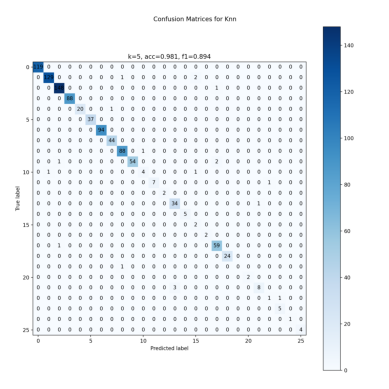

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_confusion_matrix_5.png"))
plt.axis("off")

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

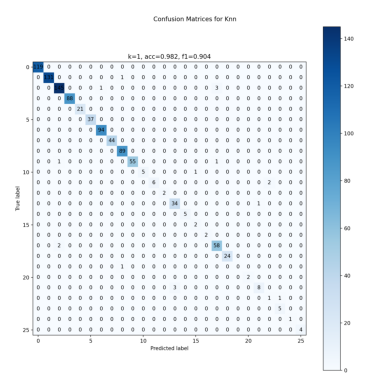

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_confusion_matrix_1.png"))
plt.axis("off")

(np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5))

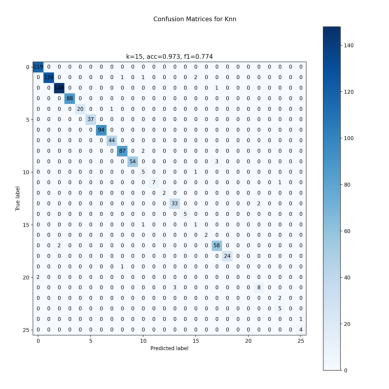

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_confusion_matrix_15.png"))
plt.axis("off")

In [ ]:
counts = pd.DataFrame(data["cell_types"]).value_counts()
idx = counts[counts > 10].index.tolist()
idx = [g[0] for g in idx]
idd = [i for i in range(len(data["cell_types"])) if data["cell_types"][i] in idx]
labels = [data["cell_types"][i] for i in idd]
emb2d = emb2d[idd,:]
emb_features = emb_features[idd,:]
colors = [
    "#8B0000", "#006400", "#00008B", "#8B8B00", "#8B0048", "#004B4B", "#4B0082",
    "#7A7A00", "#8B4513", "#005F6B", "#2E4D45", "#2F4F4F", "#3D5229", "#4B008B",
    "#006442", "#800000", "#191970", "#404040", "#5D4037", "#004D40", "#006064",
    "#8B5A2B", "#320064", "#005249", "#2E2B5F", "#556B2F"
]
colors2 = [
    "#FF3333", "#33FF33", "#3333FF", "#FFFF33", "#FF33FF", "#33FFFF", "#A0A0A0",
    "#FF6666", "#66FF66", "#6666FF", "#CCCC33", "#CC33CC", "#33CCCC", "#B0B0B0",
    "#FF0040", "#00FF40", "#0040FF", "#EEEE00", "#FF00EE", "#00EEEE", "#999999",
    "#FF7F50", "#00BFFF", "#7FFF00", "#FFD700", "#D2691E"
]

## 2d visualisations of the embbedings(cell types for colouring)

In [ ]:
visualize_2d_(emb2d, emb_features, labels, cell_type_to_cell_label_, colors2,colors, out_path="tasic_tsimcne_2d_cell_types.png")

[kNN probe]   k=1      acc=0.9890  macro-F1=0.9667
[kNN probe]   k=5      acc=0.9880  macro-F1=0.9675
[kNN probe]   k=15     acc=0.9880  macro-F1=0.9532
Saved 2-D embedding plot to tasic_tsimcne_2d_cell_types.png


(np.float64(-0.5), np.float64(2399.5), np.float64(1799.5), np.float64(-0.5))

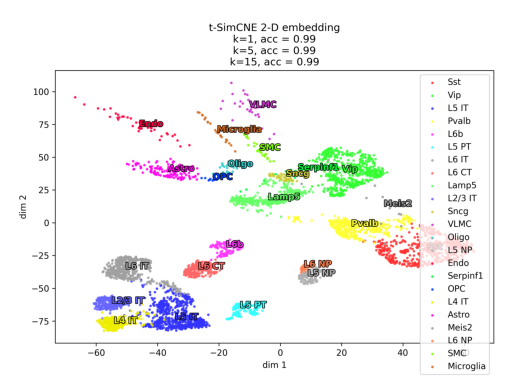

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_2d_cell_types.png") )
plt.axis("off")

In [ ]:
visualize_2d_(emb2d,emb_features, labels, cell_type_to_cell_label_, colors2,colors, out_path="tasic_tsimcne_2d_cell_types_.png", anotate=False)

[kNN probe]   k=1      acc=0.9890  macro-F1=0.9667
[kNN probe]   k=5      acc=0.9880  macro-F1=0.9675
[kNN probe]   k=15     acc=0.9880  macro-F1=0.9532
Saved 2-D embedding plot to tasic_tsimcne_2d_cell_types_.png


(np.float64(-0.5), np.float64(2399.5), np.float64(1799.5), np.float64(-0.5))

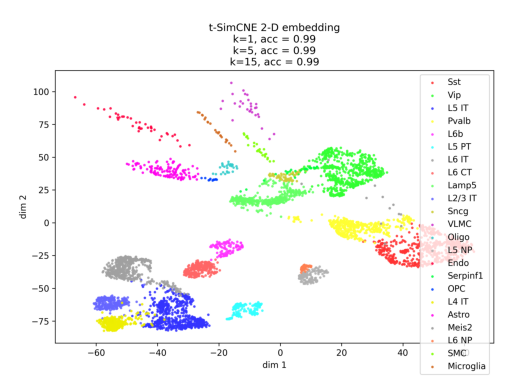

In [ ]:
plt.imshow(plt.imread("tasic_tsimcne_2d_cell_types_.png") )
plt.axis("off")

In [ ]:
#save the work
!mkdir -p /content/drive/MyDrive/drive/saves_proj_v1
!cp -r *png /content/drive/MyDrive/drive/saves_proj/
!cp -r *npy /content/drive/MyDrive/drive/saves_proj/
!cp -r *py /content/drive/MyDrive/drive/saves_proj/
!cp -r *py /content/drive/MyDrive/drive/saves_proj/
!cp -r *csv /content/drive/MyDrive/drive/saves_proj/